# Data Mining Project

Ana Rita Dias, 20250480.<br>
Catarina Santos, 20250501.

**Responsibility Statement**

We, the group members listed above, certify that this report represents our original analytical work and interpretations. While AI tools were used as specified above, all insights, conclusions, and recommendations are the result of our independent analysis and critical thinking. We take full responsibility for the accuracy and quality of this submission.


# Table of content

1. [Library imports](#1-library-imports)

2. [Importing the data](#2-importing-the-data)  
   - 2.1 [Merging the data](#21-merging-the-data)  
   - 2.2 [Metadata](#22-metadata)

3. [Clean and pre-process the data](#3-clean-and-pre-process-the-data)  
   - 3.1 [Initial analysis](#31-initial-analysis)  
   - 3.2 [Checking duplicates](#32-checking-duplicates)  
   - 3.3 [Checking missing values](#33-checking-missing-values)  
   - 3.4 [Strange values](#34-strange-values)  
   - 3.5 [Outliers: check and pre-process](#35-outliers-check-and-pre-process)  
   - 3.6 [Data scaling](#36-data-scaling)  
     - 3.6.1 [MinMaxScaler](#361-minmaxscaler)  
     - 3.6.2 [StandardScaler (Z-Score Scaling)](#362-standardscaler-z-score-scaling)  
     - 3.6.3 [Comparison of scaling methods](#363-comparison-of-scaling-methods)

4. [Segmentation perspectives](#4-segmentation-perspectives)

5. [Clustering](#5-clustering)  
   - 5.1 [K-means](#51-k-means)

6. [Clustering methods: Hierarchical Clustering](#6-clustering-methods-hierarchical-clustering)  
   - 6.1 [Demographic perspective](#61-demographic-perspective)  
     - 6.1.1 [Defining best linkage method](#611-defining-best-linkage-method)  
     - 6.1.2 [Dendrogram](#612-dendrogram)  
     - 6.1.3 [Visualize the cluster means with the cluster sizes](#613-visualize-the-cluster-means-with-the-cluster-sizes)  
   - 6.2 [Behaviour perspective](#62-behaviour-perspective)  
     - 6.2.1 [Defining best linkage method](#621-defining-best-linkage-method)  
     - 6.2.2 [Dendrogram](#622-dendrogram)  
     - 6.2.3 [Visualize the cluster means with the cluster sizes](#623-visualize-the-cluster-means-with-the-cluster-sizes)

7. [Clustering methods: Self-organizing maps](#7-clustering-methods-self-organizing-maps)  
   - 7.1 [Demographic perspective](#71-demographic-perspective)  
   - 7.2 [Behaviour perspective](#72-behaviour-perspective)

8. [Merging clusters](#8-merging-clusters)  
   - 8.1 [Final analysis of the merged](#81-final-analysis-of-the-merged)


## 1. Library imports

In [1]:
import pandas as pd
import numpy as np
import math

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler

from sklearn.metrics import silhouette_score, silhouette_samples 
from sklearn.cluster import KMeans 
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from pandas.plotting import parallel_coordinates
from minisom import MiniSom
from matplotlib import cm, colorbar
from matplotlib import colors as mpl_colors
from matplotlib.patches import RegularPolygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.cluster import MeanShift, DBSCAN, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from collections import Counter

## 2. Importing the data

In [2]:
customers = pd.read_csv("../data/DM_AIAI_CustomerDB.csv")
customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [3]:
flights = pd.read_csv('../data/DM_AIAI_FlightsDB.csv')
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


As we had seen before in the EDA, there are __multiple entries for the same customer's flights each month__, so, before merging them, we decided to modify the flights dataset to provide more comprehensive information on each customer.

In [4]:
flights_original = flights.copy() #this code was made with the help of AI

flights_aggregated = flights_original.groupby('Loyalty#').agg(
    TotalFlights=('NumFlights', 'sum'),
    TotalFlightsWithCompanions=('NumFlightsWithCompanions', 'sum'),
    TotalDistanceKM=('DistanceKM', 'sum'),
    TotalPointsAccumulated=('PointsAccumulated', 'sum'),
    TotalPointsRedeemed=('PointsRedeemed', 'sum'),
    TotalDollarCostPointsRedeemed=('DollarCostPointsRedeemed', 'sum'),
    AvgFlightsPerMonth=('NumFlights', 'mean'),
    AvgPointsPerMonth=('PointsAccumulated', 'mean'),
    MaxFlightsInMonth=('NumFlights', 'max'),
    MaxPointsInMonth=('PointsAccumulated', 'max'),
    CompanionFlightRatio=('NumFlightsWithCompanions',
        lambda x: x.sum() / flights_original.loc[x.index, 'NumFlights'].sum() if flights_original.loc[x.index, 'NumFlights'].sum() != 0 else 0),
    SoloFlightRatio=('NumFlightsWithCompanions',
        lambda x: 1 - (x.sum() / flights_original.loc[x.index, 'NumFlights'].sum() if flights_original.loc[x.index, 'NumFlights'].sum() != 0 else 0)
    ),
    PointsRatio=('PointsRedeemed',
        lambda x: x.sum() / flights.loc[x.index, 'PointsAccumulated'].sum()
        if flights.loc[x.index, 'PointsAccumulated'].sum() != 0 else 0),
    PointsRedeemedPerFlight=('PointsRedeemed',
        lambda x: x.sum() / flights_original.loc[x.index, 'NumFlights'].sum() if flights_original.loc[x.index, 'NumFlights'].sum() != 0 else 0),
    AvgCompanionsPerFlight=('NumFlightsWithCompanions',
        lambda x: x.sum() / flights_original.loc[x.index, 'NumFlights'].sum() if flights_original.loc[x.index, 'NumFlights'].sum() != 0 else 0)
).reset_index()

flights_aggregated['TotalSoloFlights'] = flights_aggregated['TotalFlights'] - flights_aggregated['TotalFlightsWithCompanions']

cols = flights_aggregated.columns.tolist()
cols.insert(cols.index('TotalFlightsWithCompanions') + 1, cols.pop(cols.index('TotalSoloFlights')))
flights_aggregated = flights_aggregated[cols]

To not lose seasonality we also add some other features.

In [5]:
flights_original['Month'] = pd.to_datetime(flights_original['YearMonthDate']).dt.month #this code was made with the help of AI
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
flights_original['Season'] = flights_original['Month'].map(season_map)
seasonal_data = flights_original.pivot_table(
    index='Loyalty#', 
    columns='Season', 
    values='NumFlights', 
    aggfunc='sum', 
    fill_value=0
)

seasonal_data.columns = [f'Flights_{col}' for col in seasonal_data.columns]
flights_aggregated = flights_aggregated.merge(seasonal_data, on='Loyalty#', how='left')


### 2.1 Merging the data

Using the function `.merge()` we joined the datasets `CustomerDB` and `FlightsDB`.

In [6]:
df = pd.merge(customers, flights_aggregated, on='Loyalty#', how='left')
pd.set_option('display.float_format', '{:.5f}'.format)
df.describe()

,Unnamed: 0,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,TotalFlights,TotalFlightsWithCompanions,TotalSoloFlights,TotalDistanceKM,...,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter
count,16921.00000,16921.00000,16921.00000,16921.00000,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000,...,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000,16901.00000
mean,8440.02364,550197.39377,47.17450,-91.81477,37758.03840,7990.46019,142.76769,35.95851,106.80919,290149.50573,...,2900.08461,0.23503,0.76497,0.28683,58.06783,0.23503,33.09498,33.16054,45.60083,30.91134
std,4884.77544,259251.50360,3.30797,22.24243,30368.99250,6863.17309,83.60019,24.15648,64.80235,170217.79013,...,1088.50062,0.13606,0.13606,0.48296,96.19848,0.13606,22.62429,25.22273,32.66680,22.15845
min,0.00000,100011.00000,42.98492,-135.05684,0.00000,1898.01000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,4210.00000,326823.00000,44.23117,-120.23766,0.00000,3979.72000,70.10000,16.00000,52.00000,143610.00000,...,2731.00000,0.16397,0.69129,0.00000,0.00000,0.16397,15.00000,11.00000,18.00000,12.00000
50%,8440.00000,550896.00000,46.08782,-79.38319,34161.00000,5780.18000,163.10000,36.80000,118.30000,331811.40000,...,3202.00000,0.23766,0.76234,0.21471,43.57668,0.23766,33.00000,33.00000,45.80000,30.80000
75%,12670.00000,772438.00000,49.28273,-74.59618,62396.00000,8945.69000,204.10000,52.90000,154.30000,414716.30000,...,3577.00000,0.30871,0.83603,0.41923,85.31707,0.30871,49.30000,51.80000,69.40000,46.90000
max,16900.00000,999999.00000,60.72119,-52.71258,99981.00000,83325.38000,539.40000,144.70000,404.00000,1059681.00000,...,4204.00000,1.00000,1.00000,33.26772,4865.00000,1.00000,148.40000,163.70000,223.70000,143.20000


We also created a copy of this original dataframe using `.copy()`.

In [7]:
df_original = df.copy

### 2.2 Metadata

* `Loyalty#` - Unique customer identifier for loyalty program members
* `First Name` - Customer's first name
* `Last Name` - Customer's last name
* `Customer Name` - Customer's full name (concatenated)
* `Province or State` - Customer's province or state
* `City` - Customer's city of residence
* `Latitude` - Geographic latitude coordinate of customer location
* `Longitude` - Geographic longitude coordinate of customer location
* `Postal code` - Customer's postal/ZIP code
* `Gender` - Customer's gender
* `Education` - Customer's highest education level (Bachelor, College, etc.)
* `Location Code` - Urban/Suburban/Rural classification of customer residence
* `Income` - Customer's annual income
* `Marital Status` - Customer's marital status (Married, Single, Divorced)
* `LoyaltyStatus` - Current tier status in loyalty program (Star > Nova > Aurora)
* `EnrollmentDateOpening` - Date when customer joined the loyalty program
* `CancellationDate` - Date when customer left the program
* `Customer Lifetime Value` - Total calculated monetary value of customer relationship
* `EnrollmentType` - Method of joining loyalty program
* `TotalFlights`: the total number of flights the customer took over the observed period.
* `TotalFlightsWithCompanions`: the total number of flights taken with companions.
* `TotalSoloFlights`: Total number of flights take solo.
* `TotalDistanceKM`: total distance traveled in kilometers.
* `TotalPointsAccumulated`: total loyalty points earned.
* `TotalPointsRedeemed`: total loyalty points spent.
* `TotalDollarCostPointsRedeemed`: total dollar value of points redeemed.
* `AvgFlightsPerMonth`: average number of flights per month.
* `AvgPointsPerMonth`: average points earned per month.
* `MaxFlightsInMonth` / `MaxPointsInMonth`: peak activity in a single month, identifying high-intensity periods.
* `CompanionFlightRatio`: proportion of flights taken with companions relative to total flights.
* `SoloflightRatio`: proportion of flights taken solo relative to total flights.
* `PointsRatio`: The proportion of the points redeemed to points accumulated.
* `PointsRedeemedPerFlight`: Average points redeemed per flight, reflecting loyalty program usage patterns.
* `AvgCompanionsPerFlight`: Average number of flights with companions per flight.
* `Flights_Fall` / `Flights_Spring` / `Flights_Summer` / `Flights_Winter`: Total number of flights per season.

## 3. Clean and pre-process the data

### 3.1 Initial analysis

Using the `.shape` method, we can visualize how many rows and columns has our datasets.<br>

In [8]:
df.shape

(16921, 41)

In this dataset, there are 16921 rows and 41 columns.

Using the `.columns` method, we can visualize the names of the columns of our datasets.<br>

In [9]:
df.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType',
       'TotalFlights', 'TotalFlightsWithCompanions', 'TotalSoloFlights',
       'TotalDistanceKM', 'TotalPointsAccumulated', 'TotalPointsRedeemed',
       'TotalDollarCostPointsRedeemed', 'AvgFlightsPerMonth',
       'AvgPointsPerMonth', 'MaxFlightsInMonth', 'MaxPointsInMonth',
       'CompanionFlightRatio', 'SoloFlightRatio', 'PointsRatio',
       'PointsRedeemedPerFlight', 'AvgCompanionsPerFlight', 'Flights_Fall',
       'Flights_Spring', 'Flights_Summer', 'Flights_Winter'],
      dtype='object')

The method `.head()` is used to take a first look at the data, displaying the first five rows (for default) of every feature in the dataset.

In [10]:
df.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.65322,-79.38319,...,3350.00000,0.29589,0.70411,0.26663,71.29694,0.29589,39.90000,46.70000,84.60000,18.40000
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.54439,-113.49093,...,3191.00000,0.11537,0.88463,0.52628,80.46507,0.11537,58.70000,84.00000,84.20000,52.20000
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.28273,-123.12074,...,2990.00000,0.33250,0.66750,0.22992,45.66333,0.33250,30.40000,38.00000,20.90000,30.70000
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.65322,-79.38319,...,3006.00000,0.29862,0.70138,0.42314,83.36651,0.29862,43.30000,67.70000,36.50000,48.40000
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.42873,-75.71336,...,2817.00000,0.36848,0.63152,0.00000,0.00000,0.36848,32.10000,28.30000,73.30000,37.00000


The method `.tail()` is used to take a first look at the data, displaying the last five rows (for default) of every feature in the dataset.

In [11]:
df.tail()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter
16916,15,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.75973,-71.14101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16917,16,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.52483,-113.54636,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16918,17,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.05187,-64.82543,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16919,18,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.86297,-71.13344,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16920,19,100016,Emma,Martin,Emma Martin,Canada,British Columbia,Dawson Creek,55.72056,-120.16009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Using these two methods made it possible to view the first and last five rows, respectively. This information can be used to draw important conclusions about the data, such as:

* There are different types of data, such as:

    * __Categorical__ -> Nominal;<br>
    * __Numerical__ -> Discrete and Continuous
* There are __missing values__, witch will be treated after.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     16921 non-null  int64  
 1   Loyalty#                       16921 non-null  int64  
 2   First Name                     16921 non-null  object 
 3   Last Name                      16921 non-null  object 
 4   Customer Name                  16921 non-null  object 
 5   Country                        16921 non-null  object 
 6   Province or State              16921 non-null  object 
 7   City                           16921 non-null  object 
 8   Latitude                       16921 non-null  float64
 9   Longitude                      16921 non-null  float64
 10  Postal code                    16921 non-null  object 
 11  Gender                         16921 non-null  object 
 12  Education                      16921 non-null 

In [13]:
df.dtypes

Unnamed: 0                         int64
Loyalty#                           int64
First Name                        object
Last Name                         object
Customer Name                     object
Country                           object
Province or State                 object
City                              object
Latitude                         float64
Longitude                        float64
Postal code                       object
Gender                            object
Education                         object
Location Code                     object
Income                           float64
Marital Status                    object
LoyaltyStatus                     object
EnrollmentDateOpening             object
CancellationDate                  object
Customer Lifetime Value          float64
EnrollmentType                    object
TotalFlights                     float64
TotalFlightsWithCompanions       float64
TotalSoloFlights                 float64
TotalDistanceKM 

Using the `.info()` and `.dtypes` methods, we can take out some information of this dataset:
- __Non-null Count__
- __Dtype__
    - int64
    - object
    - float64


### 3.2 Checking duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

With the combined functions `.duplicated().sum()` we looked for the __number of duplicated__ rows in the data set, witch were 0.

Using the same mechanism as before, we check it the feature `Loyalty#` had unique values only and it didn't. That means __different people share the same loyalty number__ or the same person is in multiple rows, so we have to take care of this issue.

In [15]:
duplicates = df[df['Loyalty#'].duplicated(keep=False)] #get all rows with duplicate Loyalty#

dup_counts = df['Loyalty#'].value_counts() #frequency of each Loyalty# duplicate
duplicates_only = dup_counts[dup_counts > 1] #filter only those that are duplicated

print("Number of unique Loyalty numbers that are duplicated:", len(duplicates_only))
print("Total rows involved in duplicates:", duplicates_only.sum())

Number of unique Loyalty numbers that are duplicated: 163
Total rows involved in duplicates: 327


There are 163 numbers repeated in at least two rows and a total of 327 rows affected by this duplication.

In [16]:
df[df['Loyalty#'] == 678205]

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter
9546,9546,678205,Arnold,Sirles,Arnold Sirles,Canada,Quebec,Hull,45.42873,-75.71336,...,3101.00000,0.23022,0.76978,0.70137,109.28777,0.23022,47.00000,43.00000,49.00000,0.00000
9995,9995,678205,Chanelle,Essman,Chanelle Essman,Canada,New Brunswick,Moncton,46.08782,-64.77823,...,3101.00000,0.23022,0.76978,0.70137,109.28777,0.23022,47.00000,43.00000,49.00000,0.00000
16408,16408,678205,Genna,Podwoski,Genna Podwoski,Canada,Ontario,London,42.98492,-81.24528,...,3101.00000,0.23022,0.76978,0.70137,109.28777,0.23022,47.00000,43.00000,49.00000,0.00000


Using the `Loyalty#` value of “678205” as an example, we found that repeated numbers did not necessarily belong to the same person. While we could modify these numbers to distinguish between different individuals, there is no way we would be able to identify which individual the flights belonged to. Therefore, we decided to first check whether these repeated `Loyalty#` entries represented a small portion of our data (≈1%) and, if so, consider deleting those rows.

In [17]:
total_rows = len(df)
rows_after_dropping_duplicates = len(df.drop_duplicates('Loyalty#'))
rows_removed = total_rows - rows_after_dropping_duplicates
percent_removed = (rows_removed / total_rows) * 100
percent_removed

0.9692098575734295

Since the percentage of deleted rows is only 0.97% of all entries in our dataset, we decided to delete them to prevent from corrupting future findings.

In [18]:
df.drop_duplicates('Loyalty#', inplace=True)


### 3.3. Checking Missing Values

With the combined functions `.isna().sum()` we checked the __missing values__ on the dataset.

In [19]:
df.replace("", np.nan, inplace=True)
df.isna().sum()

Unnamed: 0                           0
Loyalty#                             0
First Name                           0
Last Name                            0
Customer Name                        0
Country                              0
Province or State                    0
City                                 0
Latitude                             0
Longitude                            0
Postal code                          0
Gender                               0
Education                            0
Location Code                        0
Income                              20
Marital Status                       0
LoyaltyStatus                        0
EnrollmentDateOpening                0
CancellationDate                 14469
Customer Lifetime Value             20
EnrollmentType                       0
TotalFlights                        20
TotalFlightsWithCompanions          20
TotalSoloFlights                    20
TotalDistanceKM                     20
TotalPointsAccumulated   

The missing values of `Income`,  `Customer Lifetime Value ` and `CancellationDate` will be handled the same way as they were in the EDA phase.

In [20]:
df[df['Income'].isna()] # the columns with missing values are all Nan in these 20 rows

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter
16901,0,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.02926,-66.56515,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16902,1,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.57367,-73.52301,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16903,2,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.07538,-77.55038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16904,3,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.10662,-64.71427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16905,4,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.95000,-66.65244,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16906,5,999992,Ella,Roy,Ella Roy,Canada,Ontario,Toronto,43.70688,-79.43741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16907,6,999993,Elijah,Cook,Elijah Cook,Canada,British Columbia,Dawson Creek,55.70148,-120.18172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16908,7,999994,Ethan,Chan,Ethan Chan,Canada,Ontario,Ottawa,45.36591,-75.72318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16909,8,999995,Liam,Wong,Liam Wong,Canada,Ontario,Ottawa,45.47156,-75.70487,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16910,9,999996,Isabella,Ross,Isabella Ross,Canada,Ontario,Toronto,43.69049,-79.43676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df['CancellationDate'] = df['CancellationDate'].fillna('not canceled')
df.dropna(subset=['Income'],inplace=True)
df.isna().sum()


Unnamed: 0                       0
Loyalty#                         0
First Name                       0
Last Name                        0
Customer Name                    0
Country                          0
Province or State                0
City                             0
Latitude                         0
Longitude                        0
Postal code                      0
Gender                           0
Education                        0
Location Code                    0
Income                           0
Marital Status                   0
LoyaltyStatus                    0
EnrollmentDateOpening            0
CancellationDate                 0
Customer Lifetime Value          0
EnrollmentType                   0
TotalFlights                     0
TotalFlightsWithCompanions       0
TotalSoloFlights                 0
TotalDistanceKM                  0
TotalPointsAccumulated           0
TotalPointsRedeemed              0
TotalDollarCostPointsRedeemed    0
AvgFlightsPerMonth  

The rows with missing `Income` values were removed, and no other missing data remained because __those same rows contained NaNs in all columns__, beside the `CancellationDate` ones.

### 3.4. Strange Values

The dataset have some columns that are not needed and for that reason they were __removed__:
- The first column `Unnamed` is an unnecessary index column and didn't add anything needed.
- The column `Loyalty#` is unnecessary for the study.
- The columns `First Name`, `Last Name` and `Customer Name` were removed because they give us no statistics information that would be important for the project.
- The column `Country` had "Canada" for all rows and was a redundant feature. 
- The columns `Latitude`and `Longitude` are irrelevant for our futures study.
- The column `City` is a bit vague and has a lot of categories, so we opted to stay with the feature `Province or State` only.
- The column `TotalDollarCostPointsRedeemed` has the same information as the feature `TotalPointsRedeemed` and they are perfect correlated.

In [22]:
df.drop(columns=df.columns[0], inplace=True)
df.drop(columns="Loyalty#", inplace=True)
df.drop(columns=["First Name", "Last Name", 'Customer Name'], inplace=True)
df.drop(columns="Country", inplace=True) 
df.drop(columns=["Latitude", "Longitude", "Postal code"], inplace=True) 
df.drop(columns="City",inplace=True)
df.drop(columns=['TotalDollarCostPointsRedeemed'],inplace=True)
df

,Province or State,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,...,MaxPointsInMonth,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter
0,Ontario,female,Bachelor,Urban,70146.00000,Married,Star,2/15/2019,not canceled,3839.14000,...,3350.00000,0.29589,0.70411,0.26663,71.29694,0.29589,39.90000,46.70000,84.60000,18.40000
1,Alberta,male,College,Rural,0.00000,Divorced,Star,3/9/2019,not canceled,3839.61000,...,3191.00000,0.11537,0.88463,0.52628,80.46507,0.11537,58.70000,84.00000,84.20000,52.20000
2,British Columbia,male,College,Urban,0.00000,Single,Star,7/14/2017,1/8/2021,3839.75000,...,2990.00000,0.33250,0.66750,0.22992,45.66333,0.33250,30.40000,38.00000,20.90000,30.70000
3,Ontario,male,College,Suburban,0.00000,Single,Star,2/17/2016,not canceled,3839.75000,...,3006.00000,0.29862,0.70138,0.42314,83.36651,0.29862,43.30000,67.70000,36.50000,48.40000
4,Quebec,male,Bachelor,Suburban,97832.00000,Married,Star,10/25/2017,not canceled,3842.79000,...,2817.00000,0.36848,0.63152,0.00000,0.00000,0.36848,32.10000,28.30000,73.30000,37.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16896,British Columbia,female,College,Rural,0.00000,Married,Star,12/22/2015,not canceled,61850.19000,...,3457.00000,0.09230,0.90770,0.00000,0.00000,0.09230,33.50000,21.10000,63.50000,52.00000
16897,Saskatchewan,female,Bachelor,Rural,78310.00000,Married,Star,9/6/2017,not canceled,67907.27000,...,3463.00000,0.22408,0.77592,0.45333,61.07321,0.22408,80.50000,66.20000,67.50000,54.90000
16898,British Columbia,male,College,Urban,0.00000,Single,Star,3/24/2017,not canceled,74228.52000,...,3312.00000,0.17757,0.82243,0.32353,61.26558,0.17757,53.00000,65.40000,104.10000,34.30000
16899,Quebec,male,Bachelor,Urban,58958.00000,Married,Star,4/22/2021,12/22/2021,83325.38000,...,3609.00000,0.41509,0.58491,0.83738,99.00000,0.41509,20.00000,0.00000,33.00000,0.00000


The column `EnrollmentDateOpening` and `CancellationDate` have values that __do not make sense__ together, so we will treated them as they were previously in EDA.

In [23]:

df['EnrollmentDateOpening'] = pd.to_datetime(df['EnrollmentDateOpening'])
df['CancellationDate'] = df['CancellationDate'].replace('not canceled', pd.NaT)
df['CancellationDate'] = pd.to_datetime(df['CancellationDate'], errors='coerce')

mask_invalid = (df['CancellationDate'].notna()) & (
    df['EnrollmentDateOpening'] > df['CancellationDate']
)

df['AbsDaysDiff'] = (df['EnrollmentDateOpening'] - df['CancellationDate']).dt.days.abs()

swap_mask = mask_invalid & df['AbsDaysDiff'].between(800, 900)
drop_mask = mask_invalid & ~df['AbsDaysDiff'].between(800, 900)

df.loc[swap_mask, ['EnrollmentDateOpening', 'CancellationDate']] = \
df.loc[swap_mask, ['CancellationDate', 'EnrollmentDateOpening']].values

print(f"Swapped {swap_mask.sum()} rows where date reversal pattern was systematic (~850 days apart).")

df = df.drop(df[drop_mask].index)
print(f"Dropped {drop_mask.sum()} inconsistent rows with irregular date differences.")

df.drop(columns=['AbsDaysDiff'], inplace=True)

df['CancellationDate'] = df['CancellationDate'].fillna('not canceled')

Swapped 181 rows where date reversal pattern was systematic (~850 days apart).
Dropped 20 inconsistent rows with irregular date differences.


We also found it helpful to created new features:
- The binary feature `IsCanceled` that indicates whether they loalty prohram was canceled or not.
- The numerical feature `ProgramDaysDuration` that gives us the number of days that the customer has joined the loyalty program, due to the categorical nature od `EnrollmentDateOpening` and `CancelationDate`, so we decided to drop this ones.

In [24]:
df['IsCanceled'] = np.where(df['CancellationDate'].str.strip().str.lower() == 'not canceled', 'not canceled', 'canceled')
df['EnrollmentDateOpening'] = pd.to_datetime(df['EnrollmentDateOpening'])
df['CancellationDate'] = pd.to_datetime(df['CancellationDate'], errors='coerce')
last_day = pd.Timestamp('2023-01-01')
df['EffectiveEndDate'] = np.where(df['IsCanceled'] == 1,df['CancellationDate'], last_day)
df['EffectiveEndDate'] = pd.to_datetime(df['EffectiveEndDate'])
df['ProgramDaysDuration'] = (df['EffectiveEndDate'] - df['EnrollmentDateOpening']).dt.days
df.drop(columns=['EffectiveEndDate'], inplace=True)

df.drop(columns=["EnrollmentDateOpening", "CancellationDate"],inplace=True)

C:\Users\anard\AppData\Local\Temp\ipykernel_16036\4232723603.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CancellationDate'] = pd.to_datetime(df['CancellationDate'], errors='coerce')


In [25]:
df.dtypes

Province or State              object
Gender                         object
Education                      object
Location Code                  object
Income                        float64
Marital Status                 object
LoyaltyStatus                  object
Customer Lifetime Value       float64
EnrollmentType                 object
TotalFlights                  float64
TotalFlightsWithCompanions    float64
TotalSoloFlights              float64
TotalDistanceKM               float64
TotalPointsAccumulated        float64
TotalPointsRedeemed           float64
AvgFlightsPerMonth            float64
AvgPointsPerMonth             float64
MaxFlightsInMonth             float64
MaxPointsInMonth              float64
CompanionFlightRatio          float64
SoloFlightRatio               float64
PointsRatio                   float64
PointsRedeemedPerFlight       float64
AvgCompanionsPerFlight        float64
Flights_Fall                  float64
Flights_Spring                float64
Flights_Summ

Some variables are not with the correct __datatype__. For example, `TotalFlights` and `TotalFlightsWithCompanions` were floats and, since its impossible to flight half fly with a half person, we used the function `int()` to transform them in integers.

In [26]:
df['TotalFlights'] = [int(i) for i in df['TotalFlights']]
df['TotalFlightsWithCompanions'] = [int(i) for i in df['TotalFlightsWithCompanions']]
df['Flights_Summer'] = [int(i) for i in df['Flights_Summer']]
df['Flights_Winter'] = [int(i) for i in df['Flights_Winter']]
df['Flights_Spring'] = [int(i) for i in df['Flights_Spring']]
df['Flights_Fall'] = [int(i) for i in df['Flights_Fall']]

In the previous EDA, we noticed that there were customers with `PointsRatio` values bigger than 1, witch is not possible since it is impossible to have more points redeemed then accumulated, therefore we replaced these with 1.

In [27]:
df.loc[df['PointsRatio'] > 1.0, 'PointsRatio'] = 1.0

### 3.5. Outliers: Check and pre-process

Now we will check for the __outliers__ in the numeric variables.

In [28]:
numeric_only = df.select_dtypes(include=[np.number])

q1 = numeric_only.quantile(0.25)
q3 = numeric_only.quantile(0.75)
iqr = q3 - q1

outliers = ((numeric_only < (q1 - 1.5 * iqr)) | (numeric_only > (q3 + 1.5 * iqr))).sum()
outliers

Income                           0
Customer Lifetime Value       1483
TotalFlights                    21
TotalFlightsWithCompanions      44
TotalSoloFlights                23
TotalDistanceKM                 22
TotalPointsAccumulated          22
TotalPointsRedeemed            197
AvgFlightsPerMonth               0
AvgPointsPerMonth                0
MaxFlightsInMonth             1682
MaxPointsInMonth              1822
CompanionFlightRatio           315
SoloFlightRatio                315
PointsRatio                      0
PointsRedeemedPerFlight        369
AvgCompanionsPerFlight         315
Flights_Fall                    28
Flights_Spring                  15
Flights_Summer                  21
Flights_Winter                  14
ProgramDaysDuration              0
dtype: int64

To choose the appropriate method for handling __outliers__, we first need to calculate their __percentage__ in the dataset. If they make up __less than 5%__, it is generally safe to remove them. However, if they __exceed 5%__, a different treatment approach should be considered.

In [29]:
outlier_mask = ((numeric_only < (q1 - 1.5 * iqr)) | (numeric_only > (q3 + 1.5 * iqr)))
outlier_rows = outlier_mask.any(axis=1)
num_outlier_rows = outlier_rows.sum()

print(f"The presence of outliers is {(num_outlier_rows/len(df))*100:.2f}% of the dataset.")

The presence of outliers is 23.01% of the dataset.


Since outliers make up __23.01%__ of the data, we need to handle them in another way instead of just deleting them, as that would cause too much data loss. To help decide what to do, we created __boxplots__ for the numerical variables and __bar plots__ for the categorical ones, making it easier to choose the right approach.

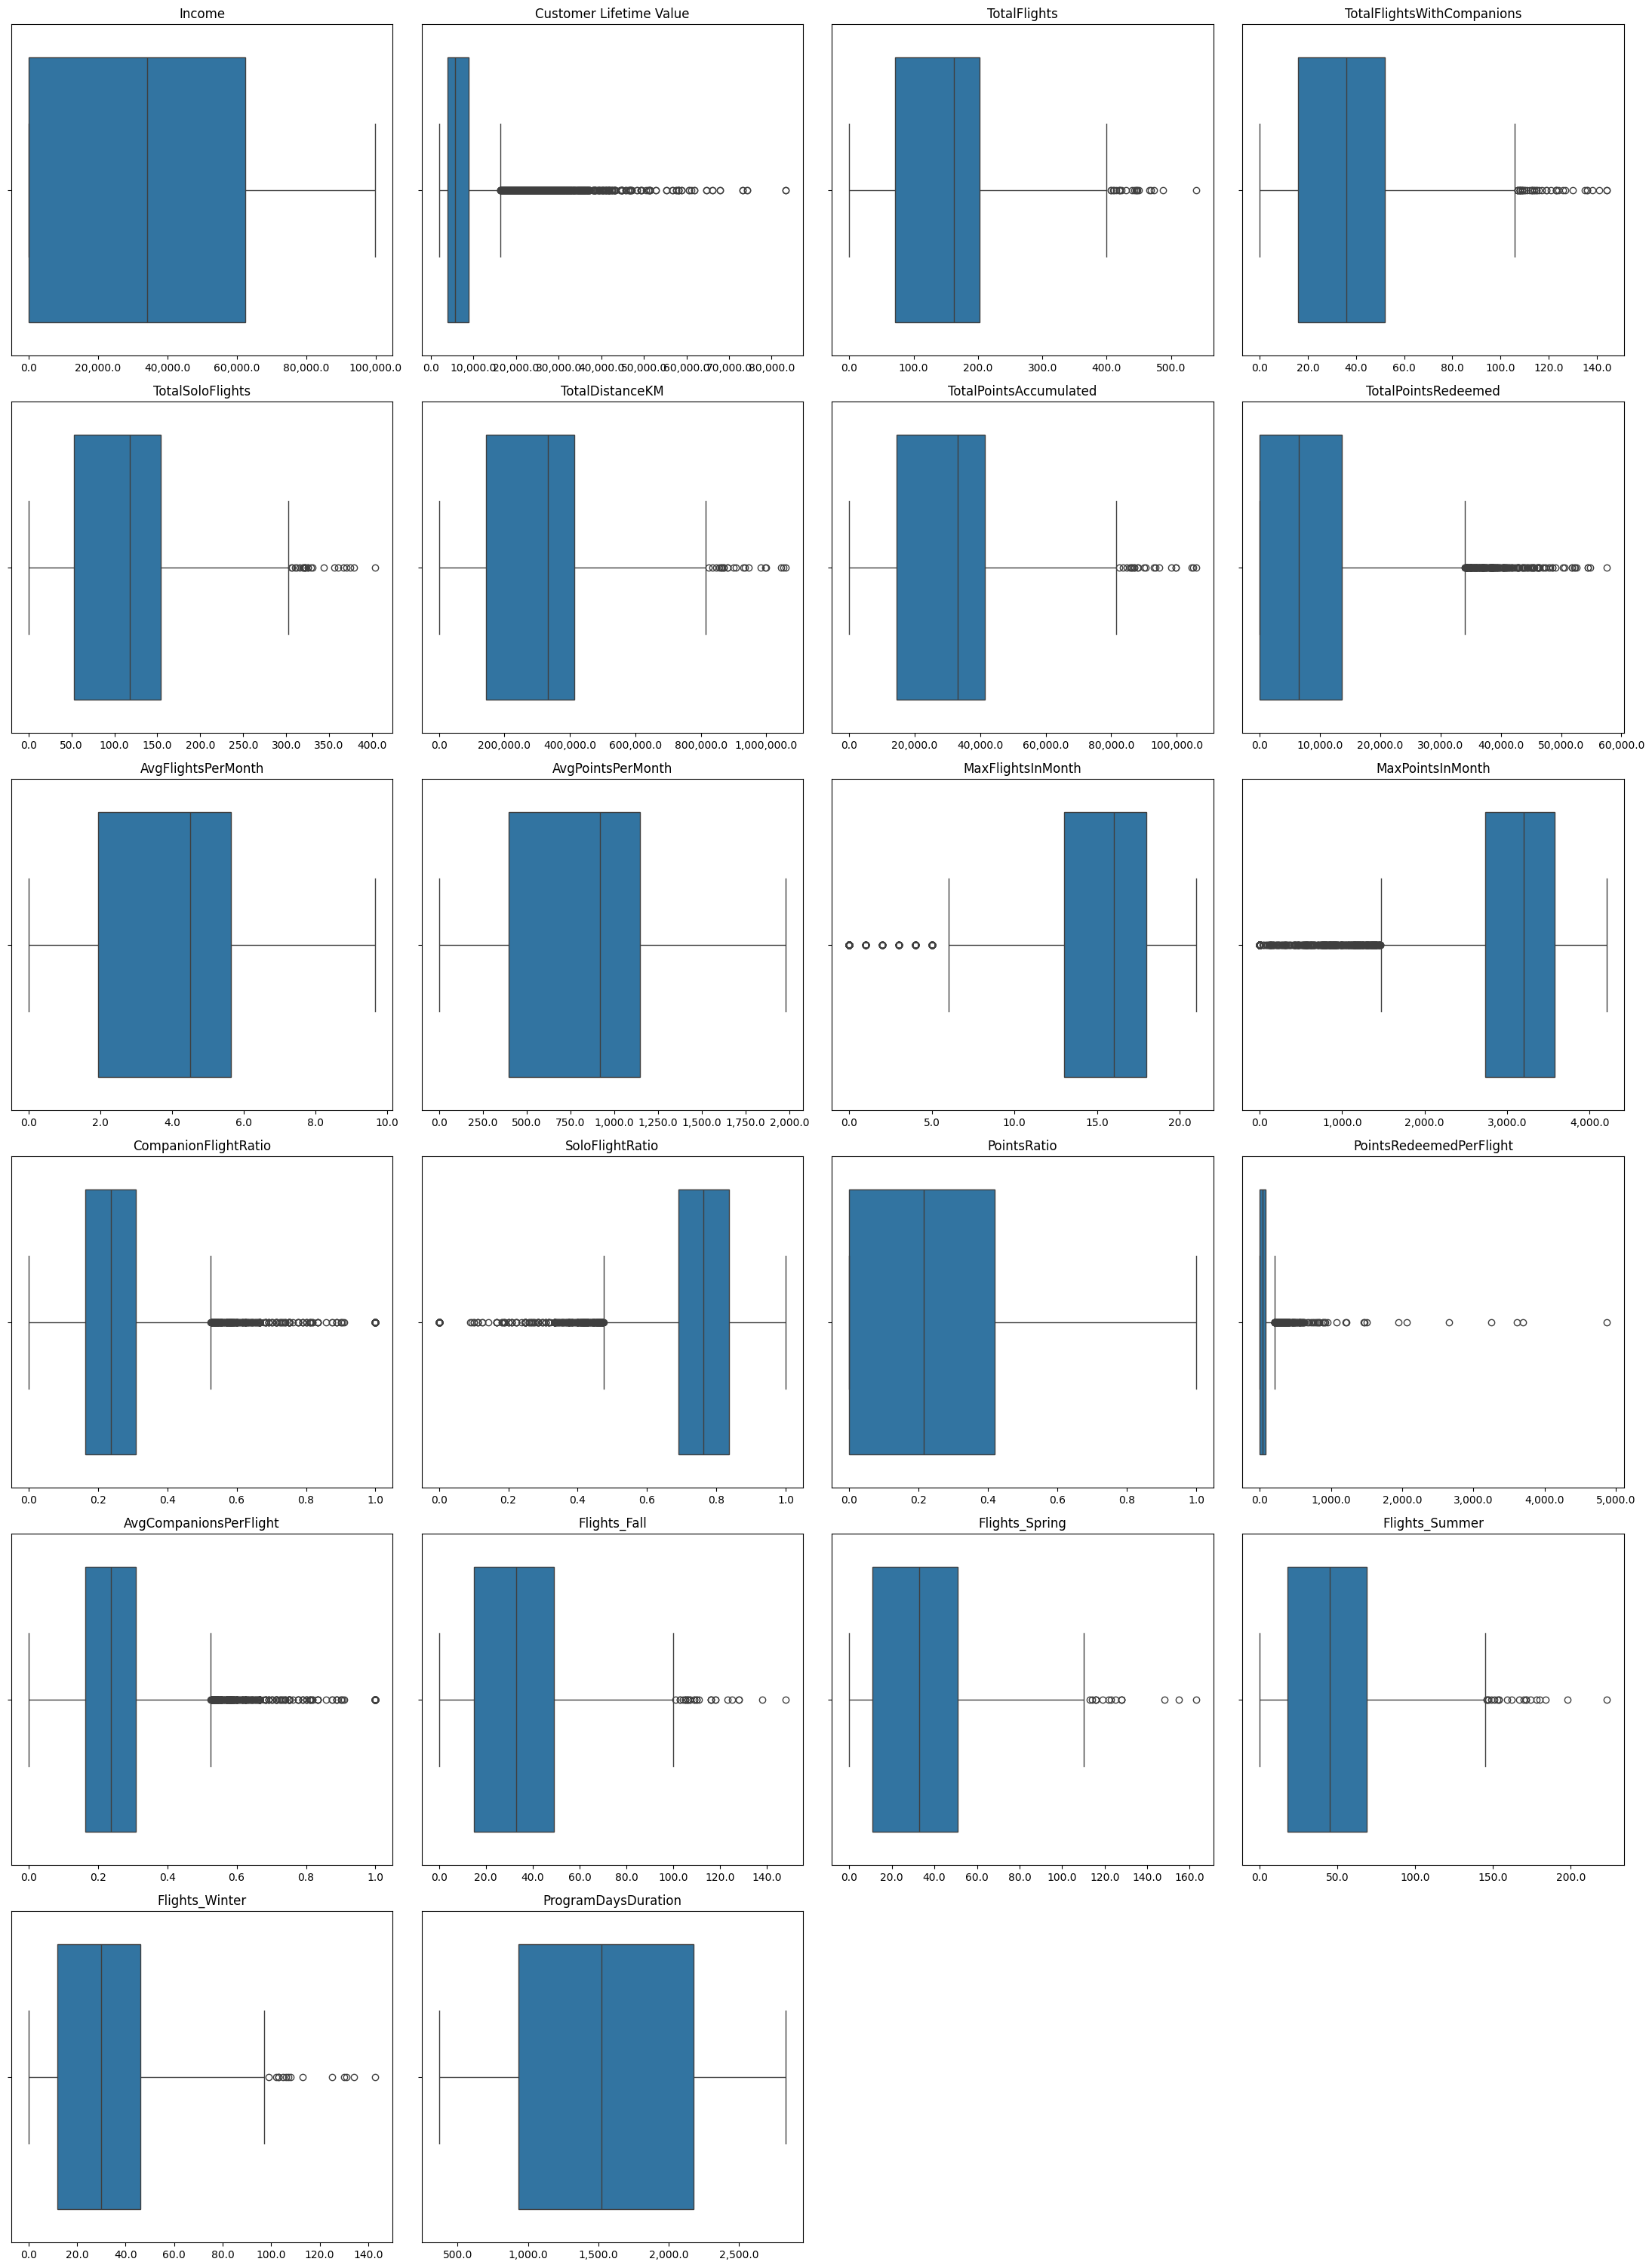

In [30]:
#boxplot for all numeric variables
numeric_only = df.select_dtypes(include=[np.number])

num_cols = 4
num_rows = math.ceil(len(numeric_only) / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(22, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_only):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    axes[i].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.1f}')) #TotalDistanceKM shows the intire numbers with this


# Remove unused axes
for k in range(i + 1, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

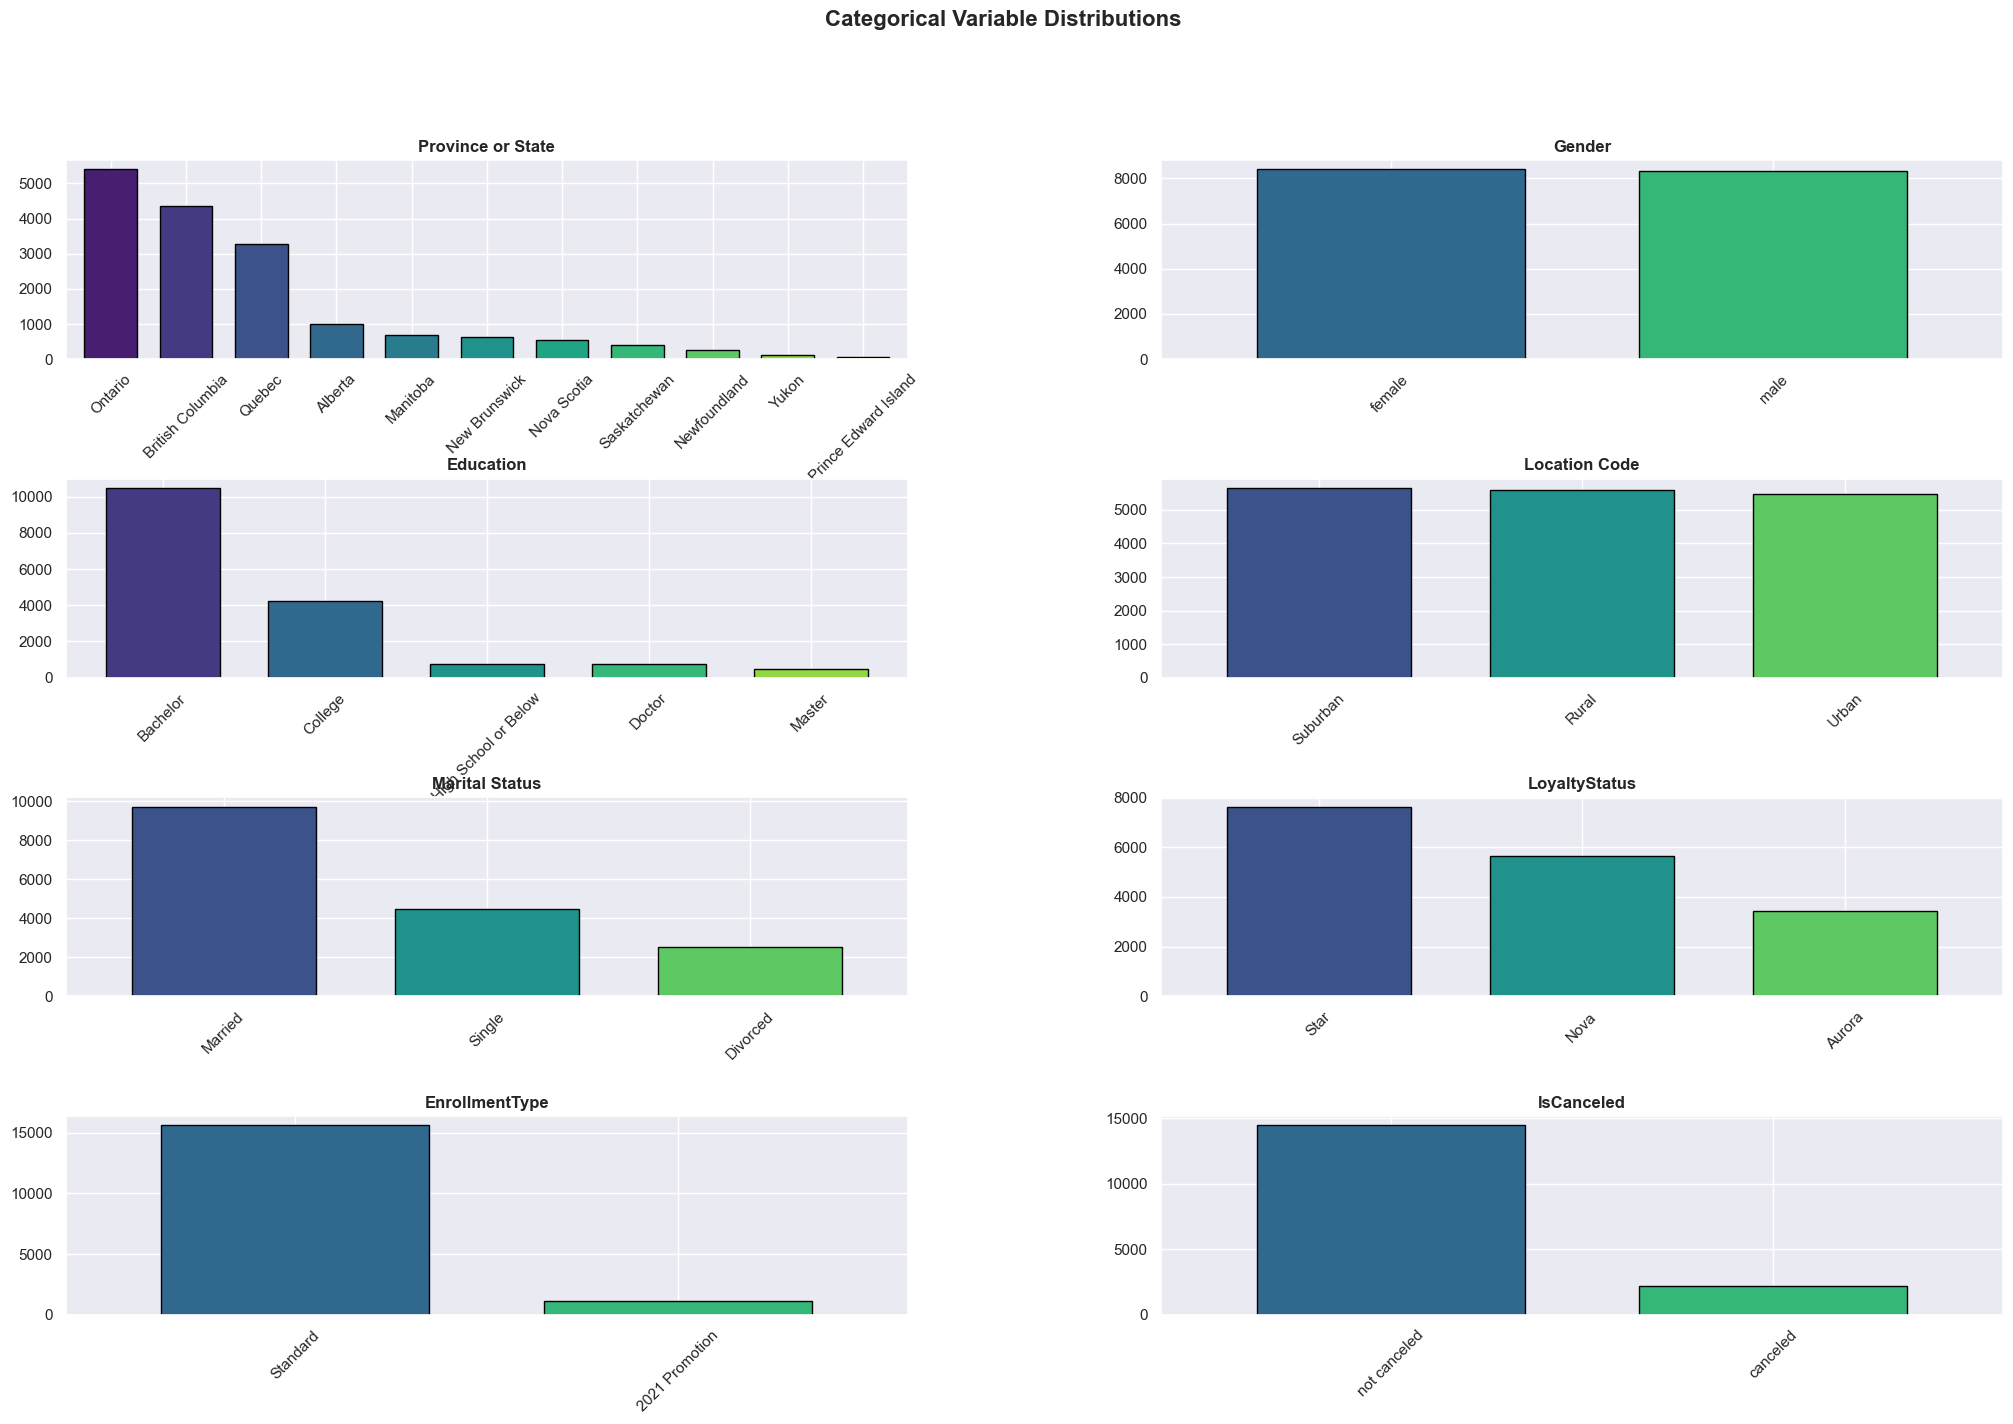

In [31]:
cat_vars = ['Province or State', 'Gender', 'Education', 'Location Code',
            'Marital Status', 'LoyaltyStatus', 'EnrollmentType','IsCanceled']

sns.set(style="darkgrid")
fig, axes = plt.subplots(4, 2, figsize=(25, 15))

for ax, feat in zip(axes.flatten(), cat_vars):
    colors = sns.color_palette('viridis', n_colors=df[feat].nunique())
    df[feat].value_counts().plot.bar(
        ax=ax, 
        width=0.7, 
        color=colors, 
        edgecolor='black'
    )
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.suptitle("Categorical Variable Distributions", fontsize=16, fontweight='bold')
plt.show()

We decide to applied the `Capping (Winsorizing)` method. This method __limits extreme outliers__ in a dataset to a specified percentile range (in this case, 0.01 and 0.99). We chose this approach because removing such a high percentage of data would cause significant information loss, while __Capping__ allows us to reduce the influence of extreme values without discarding entire rows.

In [32]:
for col in numeric_only:
    l = df[col].quantile(0.99)
    u = df[col].quantile(0.01)
    df[col] = df[col].clip(lower=l,upper=u)

### 3.6. Data scaling

For data scaling, we were unsure which method to use because both __MinMaxScaler__ and __StandardScaler__ are sensitive to outliers. To address this uncertainty, we applied both methods and compared their results.

#### 3.6.1. MinMaxScaler

Normalize the numerical data using the `MinMaxScaler` from __sklearn__. By default, this function applies the following formula:

$$X_{\text{scaled}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}},$$

where:
- $X$ is the original feature vector,
- $X_{\\{min}}$ is the smallest value in that feature column, and
- $X_{\\{max}}$ is the largest value in that feature column.

In [33]:
df_notscalled = df.copy
variables_to_scale = df.select_dtypes(include=np.number)

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform
scaled_array = scaler.fit_transform(variables_to_scale)

# Convert back to DataFrame
df_minmax = pd.DataFrame(scaled_array, columns=variables_to_scale.columns, index=df.index)

#visual confirmation
df_minmax.describe()

,Income,Customer Lifetime Value,TotalFlights,TotalFlightsWithCompanions,TotalSoloFlights,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,...,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter,ProgramDaysDuration
count,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,...,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000
mean,0.38574,0.16810,0.48952,0.38845,0.45798,0.49708,0.49708,0.24331,0.50698,0.50821,...,0.37158,0.62842,0.26634,0.19339,0.37158,0.39156,0.36688,0.38120,0.37525,0.48765
std,0.31007,0.18749,0.27946,0.25641,0.27144,0.28344,0.28344,0.24444,0.28853,0.28918,...,0.20217,0.20217,0.26645,0.20369,0.20217,0.26314,0.27530,0.26847,0.26610,0.29591
min,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,0.00000,0.05196,0.24581,0.17582,0.22748,0.25018,0.25017,0.00000,0.25205,0.25480,...,0.26171,0.50792,0.00000,0.00000,0.26171,0.18072,0.12360,0.15254,0.14815,0.22752
50%,0.34912,0.10531,0.56433,0.39560,0.51064,0.57298,0.57297,0.18689,0.58500,0.58779,...,0.37909,0.62091,0.21559,0.15262,0.37909,0.39759,0.37079,0.38136,0.37037,0.47295
75%,0.63768,0.19907,0.70281,0.57143,0.66388,0.71507,0.71508,0.38974,0.72954,0.73267,...,0.49208,0.73829,0.41985,0.29870,0.49208,0.59036,0.57303,0.58475,0.56790,0.74463
max,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000


`MinMaxScaler` transforms the data to a fixed range, typically 0 to 1 (as you may see, min=0 and max=1), while preserving the original distribution shape (but compressing the values).

#### 3.6.2. StandardScaler (Z-Score Scaling)

This method __standardize features by removing the mean and scaling to unit variance__. The standard score of a sample x is calculated as:
$$
z = \frac{x - \mu}{\sigma}
$$
Where:
- $u$ is the mean of the training samples,
- $\sigma$ is the standard deviation of the training samples
The standard deviation $\sigma$ is given by:
$$
\sigma = \sqrt{\frac{\sum_{i=1}^{N} (x_i - \bar{x})^2}{N - \text{ddof}}}
$$
Where:
- $x_i$ = each data point  
- $\bar{x}$ = mean of the data  
- $N$ = number of observations  
- $\text{ddof}$ = delta degrees of freedom  
    - ddof = 0 in population 
    - ddof = 1 in sample


In [34]:
df_scaled = df.copy()
numeric_cols = df_scaled.select_dtypes(include=['number']).columns.tolist()


scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_scaled[numeric_cols])

df_standard = pd.DataFrame(
    scaled_array,
    columns=numeric_cols,
    index=df_scaled.index
)

df_standard.head()

,Income,Customer Lifetime Value,TotalFlights,TotalFlightsWithCompanions,TotalSoloFlights,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,...,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter,ProgramDaysDuration
0,1.06797,-0.64205,0.58979,0.88506,0.43574,1.33563,1.33583,0.58684,0.60563,1.35357,...,0.49461,-0.49461,0.00107,0.27332,0.49461,0.29764,0.54478,1.23172,-0.57511,-0.19897
1,-1.24409,-0.64197,1.70478,-0.14355,1.99689,0.84680,0.84667,1.63325,1.70877,0.86102,...,-0.92849,0.92849,0.97558,0.43055,-0.92849,1.16760,2.09574,1.23172,1.00237,-0.22995
2,-1.24409,-0.64195,-0.26504,0.15646,-0.41347,-0.30142,-0.30144,-0.35403,-0.26173,-0.29504,...,0.78326,-0.78326,-0.13669,-0.16630,0.78326,-0.11444,0.21826,-0.78860,-0.01835,0.61922
3,-1.24409,-0.64195,0.66412,0.97078,0.49776,0.59822,0.59823,0.91617,0.68414,0.61086,...,0.51618,-0.51618,0.58849,0.48031,0.51618,0.48079,1.40189,-0.28352,0.81679,1.34164
4,1.98051,-0.64147,0.35440,1.14221,0.02704,0.49594,0.49591,-0.99541,0.37010,0.50783,...,1.06693,-1.06693,-0.99962,-0.94943,1.06693,-0.02286,-0.18988,0.88448,0.30642,0.47417


In [35]:
df_standard.describe()

,Income,Customer Lifetime Value,TotalFlights,TotalFlightsWithCompanions,TotalSoloFlights,TotalDistanceKM,TotalPointsAccumulated,TotalPointsRedeemed,AvgFlightsPerMonth,AvgPointsPerMonth,...,CompanionFlightRatio,SoloFlightRatio,PointsRatio,PointsRedeemedPerFlight,AvgCompanionsPerFlight,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter,ProgramDaysDuration
count,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,...,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000,16717.00000
mean,0.00000,0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.00000,...,-0.00000,0.00000,-0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000
std,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,...,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003,1.00003
min,-1.24409,-0.89662,-1.75170,-1.51502,-1.68729,-1.75383,-1.75378,-0.99541,-1.75717,-1.75745,...,-1.83802,-3.10846,-0.99962,-0.94943,-1.83802,-1.48805,-1.33270,-1.41995,-1.41025,-1.64805
25%,-1.24409,-0.61948,-0.87209,-0.82928,-0.84921,-0.87112,-0.87113,-0.99541,-0.88359,-0.87631,...,-0.54350,-0.59604,-0.99962,-0.94943,-0.54350,-0.80124,-0.88373,-0.85174,-0.85349,-0.87915
50%,-0.11812,-0.33490,0.26768,0.02789,0.19402,0.26780,0.26776,-0.23082,0.27040,0.27521,...,0.03711,-0.03711,-0.19050,-0.20012,0.03711,0.02292,0.01419,0.00059,-0.01835,-0.04970
75%,0.81252,0.16521,0.76323,0.71363,0.75857,0.76912,0.76915,0.59903,0.77137,0.77624,...,0.59604,0.54350,0.57612,0.51702,0.59604,0.75551,0.74886,0.75821,0.72399,0.86847
max,1.98107,4.43724,1.82668,2.38511,1.99689,1.77442,1.77440,3.09563,1.70877,1.70068,...,3.10846,1.83802,2.75350,3.96009,3.10846,2.31227,2.29982,2.30502,2.34788,1.73150


#### 3.6.3. Comparison of Scaling Methods: MinMaxScaler vs StandardScaler

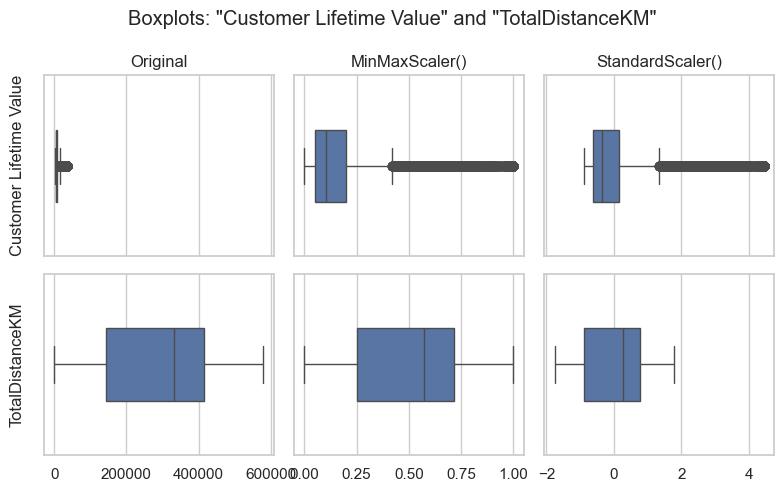

In [36]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2,3, figsize=(8,5), tight_layout=True, sharex='col', sharey='row')

bp_feat_l = 'Customer Lifetime Value'

sns.boxplot(df, x=bp_feat_l, ax=axes[0][0], width=.4)
axes[0][0].set_title('Original')
axes[0][0].set_ylabel(bp_feat_l)

sns.boxplot(df_minmax, x=bp_feat_l, ax=axes[0][1], width=.4)
axes[0][1].set_title('MinMaxScaler()')

sns.boxplot(df_standard, x=bp_feat_l, ax=axes[0][2], width=.4)
axes[0][2].set_title('StandardScaler()')



bp_feat_r = 'TotalDistanceKM'

sns.boxplot(df, x=bp_feat_r, ax=axes[1][0], width=.4)
axes[1][0].set_ylabel(bp_feat_r)

sns.boxplot(df_minmax, x=bp_feat_r, ax=axes[1][1], width=.4)

sns.boxplot(df_standard, x=bp_feat_r, ax=axes[1][2], width=.4)


axes[1][0].set_xlabel(None)
axes[1][1].set_xlabel(None)
axes[1][2].set_xlabel(None)

fig.suptitle('Boxplots: "{}" and "{}"'.format(bp_feat_l, bp_feat_r))
plt.show()

With the __boxplots__ of the `Original`, `MinMaxScaler()` and `StandardScaller` we decided to stay with the last one, since it successfully __centers__ both data distributions at the same point (0), making them visually normalized and more suitable for direct comparison or use in analytical models. It provides a more balanced and centered representation of the data.

In [37]:
df_final = df_standard 
df_final.columns

Index(['Income', 'Customer Lifetime Value', 'TotalFlights',
       'TotalFlightsWithCompanions', 'TotalSoloFlights', 'TotalDistanceKM',
       'TotalPointsAccumulated', 'TotalPointsRedeemed', 'AvgFlightsPerMonth',
       'AvgPointsPerMonth', 'MaxFlightsInMonth', 'MaxPointsInMonth',
       'CompanionFlightRatio', 'SoloFlightRatio', 'PointsRatio',
       'PointsRedeemedPerFlight', 'AvgCompanionsPerFlight', 'Flights_Fall',
       'Flights_Spring', 'Flights_Summer', 'Flights_Winter',
       'ProgramDaysDuration'],
      dtype='object')

### 3.7. Correlation

Before preceding with __clustering__ we had to identify and remove __redundant features__, we analyzed the correlation between variables. __Correlation__ measures the strength and direction of the relationship between two variables, helping to detect features that provide similar information. Highly correlated features can introduce __multicollinearity__, which may negatively affect certain models.

#### 3.7.1. Heatmap

We visualized the correlations by creating a __Heatmap__, which provides an intuitive overview of the relationships among all features in the dataset.

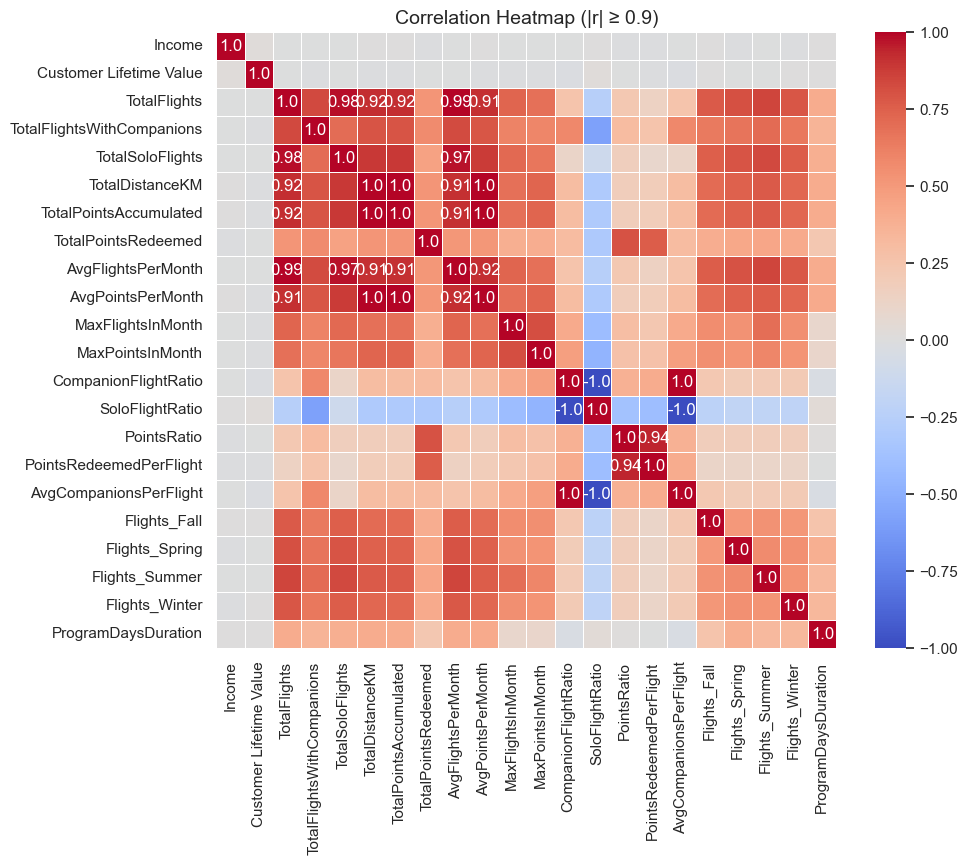

In [38]:
correlation_matrix = df_final.corr(method='pearson')

mask_annot = np.abs(correlation_matrix) >= 0.9

annot = np.where(mask_annot, 
                 np.round(correlation_matrix, 2).astype(str), 
                 "")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=annot, 
            fmt="", 
            cmap="coolwarm", 
            center=0,
            linewidths=0.6)

plt.title("Correlation Heatmap (|r| ≥ 0.9)", fontsize=14)
plt.show()


#### 3.7.2. Decisions

From the heatmap, we observed __strong correlations__ between several variables, specifically between `TotalFlights` and five others(`TotalDistanceKM`, `TotalSoloFlights`,`TotalPointsAccumulated`, `AvgFlightsPerMonth`, and `AvgPointsPerMonth`). 

Then, `AvgFlightsPerMonth` is also strongly correlated with: `TotalSoloFlights` , `TotalDistanceKM` and `TotalPointsAccumulated`.

There are perfect correlations between `AvgPointsPerMonth` and 2 variables (`TotalDistanceKM` and `TotalPointsAccumulated`), but `AvgPointsPerMonth` has also a strong correlation with `AvgFlightsPerMonth`.

Additionally, there is a __perfect correlation__ between `AvgCompanionsPerFlight` and `CompanionFlightRatio`, and also a 0.94 correlation between `PointsRatio` and `PointsRedeemedPerFlight`. 

Finally `SoloFlightRatio`is __negatively perfect correlated__ (-1.00) with `CompanionFlightRatio` and `AvgCompanionsPerFlight`. 

Therefore, we decided to drop the following features: `TotalDistanceKM`,`TotalSoloFlights`,`TotalpointsAccumulated`, `AvgFlightsPerMonth`,`SoloFlightRatio`,`PointsRedeemedPerFlight`, `AvgPointsPerMonth`, and `AvgCompanionsPerFlight`.

In [39]:
vars_to_drop = [   
    'AvgPointsPerMonth',      
    'AvgFlightsPerMonth',      
    'TotalSoloFlights',         
    'TotalDistanceKM',
    'TotalPointsAccumulated',    
    'AvgCompanionsPerFlight',
    'PointsRedeemedPerFlight',
    'CompanionFlightRatio'
]

df_final = df_final.drop(columns=vars_to_drop)
df_final

,Income,Customer Lifetime Value,TotalFlights,TotalFlightsWithCompanions,TotalPointsRedeemed,MaxFlightsInMonth,MaxPointsInMonth,SoloFlightRatio,PointsRatio,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter,ProgramDaysDuration
0,1.06797,-0.64205,0.58979,0.88506,0.58684,0.09267,0.41247,-0.49461,0.00107,0.29764,0.54478,1.23172,-0.57511,-0.19897
1,-1.24409,-0.64197,1.70478,-0.14355,1.63325,0.27567,0.26553,0.92849,0.97558,1.16760,2.09574,1.23172,1.00237,-0.22995
2,-1.24409,-0.64195,-0.26504,0.15646,-0.35403,-0.45633,0.07977,-0.78326,-0.13669,-0.11444,0.21826,-0.78860,-0.01835,0.61922
3,-1.24409,-0.64195,0.66412,0.97078,0.91617,0.09267,0.09456,-0.51618,0.58849,0.48079,1.40189,-0.28352,0.81679,1.34164
4,1.98051,-0.64147,0.35440,1.14221,-0.99541,0.45867,-0.08011,-1.06693,-0.99962,-0.02286,-0.18988,0.88448,0.30642,0.47417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16896,-1.24409,4.43724,0.35440,-0.87214,-0.99541,0.64167,0.51136,1.11038,-0.99962,0.02292,-0.47559,0.56881,1.00237,1.42191
16897,1.33706,4.43724,1.58089,1.05649,0.92826,0.09267,0.51690,0.07147,0.70177,2.17491,1.36108,0.69508,1.09517,0.54317
16898,-1.24409,4.43724,1.41983,0.41362,0.84612,1.00767,0.37735,0.43814,0.21463,0.93866,1.32026,1.86308,0.16723,0.77694
16899,0.69920,4.43724,-1.09509,-0.57213,-0.38125,-0.27333,0.65183,-1.43440,2.14315,-0.57231,-1.33270,-0.37822,-1.41025,-1.32134


We used the __correlation matrix__ to identify pairs of variables with a correlation coefficient greater than 0.9 and then removed one variable from each highly correlated pair to reduce __multicollinearity__. This helps ensure that the remaining variables provide unique information, improves model stability and interpretability, and prevents redundant features from disproportionately influencing the analysis or predictive model.

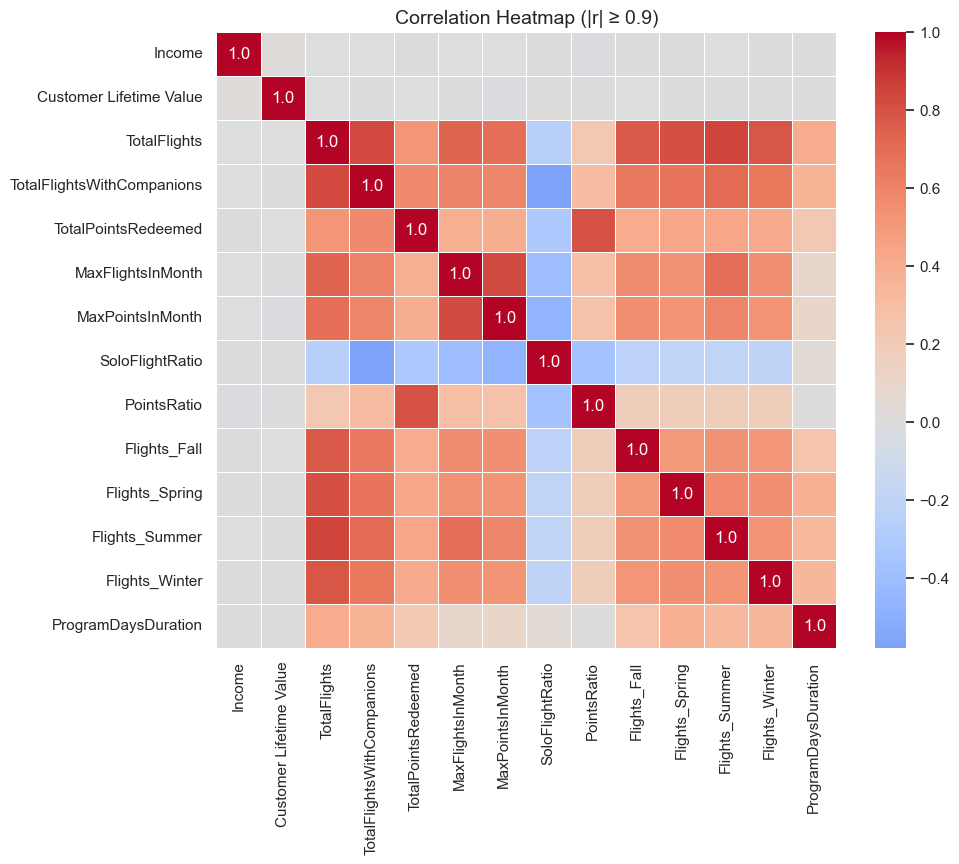

In [40]:
correlation_matrix = df_final.corr(method='pearson')

mask_annot = np.abs(correlation_matrix) >= 0.9

annot = np.where(mask_annot, 
                 np.round(correlation_matrix, 2).astype(str), 
                 "")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=annot, 
            fmt="", 
            cmap="coolwarm", 
            center=0,
            linewidths=0.6)

plt.title("Correlation Heatmap (|r| ≥ 0.9)", fontsize=14)
plt.show()

As shown before, we used a __correlation__ matrix to identify pairs of variables with correlation coefficients greater than 0.9 and removed one variable from each highly correlated pair in order to __reduce multicollinearity__. This step ensures that the remaining variables provide distinct information, improving the stability and interpretability of the analysis. With multicollinearity effectively addressed, the dataset is now suitable for moving forward with segmentation perspectives. A final __correlation matrix__ was included to verify that all correlations of 0.90 or higher were successfully dropped.

### 3.8. DBSCAN for multivariate outliers

##### Using a K-distance plot to find epsilon

- **MinPts**: As a rule of thumb, **minPts = 2 x dim** can be used, but it may be necessary to choose larger values for very large data, for noisy data or for data that contains many duplicates.

- **ε**: The value for ε can then be chosen by using a **k-distance graph**, plotting the distance to the kth (k = minPts - 1) nearest neighbor ordered from the largest to the smallest value. Good values of ε are where this plot shows an **"elbow"**: if ε is chosen much too small, a large part of the data will not be clustered; whereas for a too high value of ε, clusters will merge and the majority of objects will be in the same cluster. 

The assumption is that for points **in a cluster**, their k nearest neighbors are at roughly the same distance. **Noise points** have their k-th nearest neighbors at farther distance

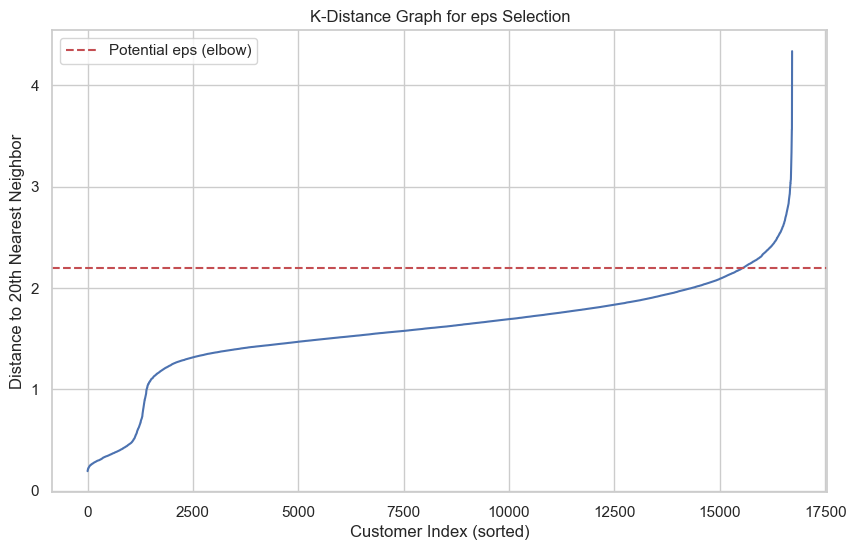

In [41]:
# Find optimal eps using K-distance method
neigh = NearestNeighbors(n_neighbors=20) # n_features * 2 as a rule of thumb
neigh.fit(df_final)
distances, _ = neigh.kneighbors(df_final)
# matrix of n_samples x n_neighbors nearest neighbors distances
distances = np.sort(distances[:, -1])
# distances for every sample to the 20th nearest neighbor, sorted


plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection")
plt.xlabel("Customer Index (sorted)")
plt.ylabel("Distance to 20th Nearest Neighbor")
plt.grid(True)

plt.axhline(y=2.2, color='r', linestyle='--', label='Potential eps (elbow)')

plt.legend()
plt.show()


From our graphic , we can assume that the epsilon has 2.2 value.

In [42]:
dbscan = DBSCAN(eps=2.2, min_samples=50, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(df_final)
Counter(dbscan_labels)

Counter({np.int64(0): 16321, np.int64(-1): 396})

In [43]:
df_outliers = df_final[dbscan_labels == -1].copy()
df_out = df_final[dbscan_labels != -1].copy()
print('Percentage of data kept after removing outliers:', np.round(df_out.shape[0] / df_final.shape[0], 4))

Percentage of data kept after removing outliers: 0.9763


## 4. Segmentation perspectives

__Segmentation perspectives__ involve dividing a dataset into distinct groups/segments based on specific characteristics or patterns. This approach helps to better understand the underlying structure of data and identify subgroups.

### 4.1. Defining perspectives

We divided the segmentation analysis into __demographic__ and __behavioral__ perspectives to capture different aspects of customers.

The __demographic perspective__ focuses on personal and financial attributes, which help identify high-value or potentially profitable customers.

The __behavioral perspective__ focuses on customer travel behavior and engagement.

By combining these __perspectives__, we can create more meaningful and actionable segments that reflect both who the customers are and how they behave.

In [44]:
#number of columns and their names
print(df_out.shape[1])
print(df_out.columns)

14
Index(['Income', 'Customer Lifetime Value', 'TotalFlights',
       'TotalFlightsWithCompanions', 'TotalPointsRedeemed',
       'MaxFlightsInMonth', 'MaxPointsInMonth', 'SoloFlightRatio',
       'PointsRatio', 'Flights_Fall', 'Flights_Spring', 'Flights_Summer',
       'Flights_Winter', 'ProgramDaysDuration'],
      dtype='object')


##### Demographic perspectives: Group customers based on their economic value.

In [45]:
demographic_features = [
    'Income',
    'Customer Lifetime Value',
    'ProgramDaysDuration',
    'TotalFlights',
    'TotalPointsRedeemed',
]

print("Demographic features:", demographic_features)

Demographic features: ['Income', 'Customer Lifetime Value', 'ProgramDaysDuration', 'TotalFlights', 'TotalPointsRedeemed']


##### Behaviour perspectives: Group customers based on their flight preference.

In [46]:
behaviour_features = ['Flights_Summer',
    'Flights_Spring',
    'Flights_Winter',
    'Flights_Fall',
    'TotalFlightsWithCompanions',
    'PointsRatio',
    'SoloFlightRatio',
    'MaxFlightsInMonth',
    'MaxPointsInMonth']
print("Behaviour features:", behaviour_features)

Behaviour features: ['Flights_Summer', 'Flights_Spring', 'Flights_Winter', 'Flights_Fall', 'TotalFlightsWithCompanions', 'PointsRatio', 'SoloFlightRatio', 'MaxFlightsInMonth', 'MaxPointsInMonth']


##### Combining metric features

The __demographic__ and __behavioral__ variables were combined into a single dataset ( __metric_features__ ), for use in the segmentation analysis.

In [47]:
metric_features = demographic_features + behaviour_features
print("Total metric features:", len(metric_features))

Total metric features: 14


##### Univariance

In [48]:
round(df_out.var(), 3)

Income                       0.99900
Customer Lifetime Value      0.72300
TotalFlights                 0.99800
TotalFlightsWithCompanions   0.99000
TotalPointsRedeemed          0.96800
MaxFlightsInMonth            1.01200
MaxPointsInMonth             1.01400
SoloFlightRatio              0.99300
PointsRatio                  0.97600
Flights_Fall                 0.99100
Flights_Spring               0.99400
Flights_Summer               0.99200
Flights_Winter               0.99100
ProgramDaysDuration          1.00000
dtype: float64

There is no low variance features to drop.

## 5. Clustering

__Clustering__ is an unsupervised learning technique used to group data points into __clusters__ based on their __similarity__. The goal is to ensure that data points within the same cluster are more similar to each other than to those in other clusters. 

__Clustering__ helps uncover hidden patterns, identify distinct segments, and provide insights that can guide decision making, marketing strategies, or customer targeting.

### 5.1 K-means

We decided for this first analysis to apply the `K-Means` since we check all the characteristics:
- __Number of clusters__ need to be set apriori.
- One of the __fastest__ clustering algorithms.
- The results __depend on the initialization__ (stochastic).

In [49]:
df_dem = df_out[demographic_features].copy()
df_beh = df_out[behaviour_features].copy()

#### 5.1.1. Demographic perspectives

 ##### Defining number of clusters:
 To define the number of clusters we created a graph of the __Elbow Curve__ using the __Inertia function__:
$$\sum_{j=0}^{C}\sum_{i=0}^{n_j}(||x_i - \mu_j||^2)$$
Where:
* $C$: Set of identified clusters.
* $n_j$: Set of observations belonging to cluster $j$.
* $x_i$: Observation $i$.
* $\mu_j$: Centroid of cluster $j$.

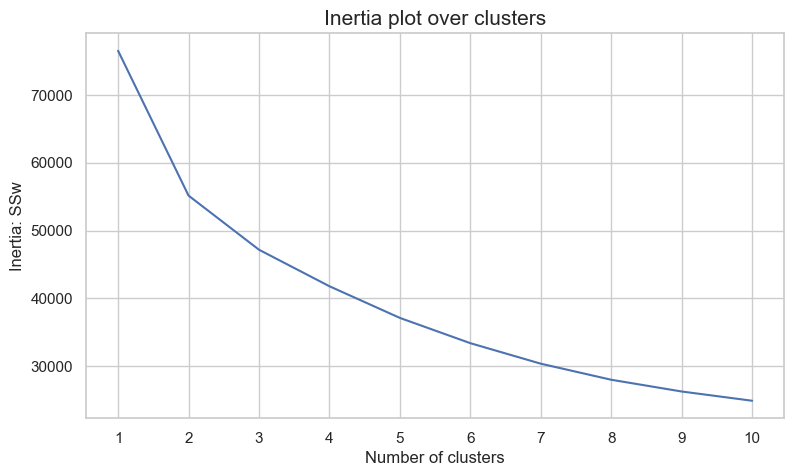

In [50]:
# Demographic features
range_clusters = range(1,11)

inertia = []
for n_clus in range_clusters:  # iterate over desired ncluster range
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df_dem)
    inertia.append(kmclust.inertia_)


fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

The __elbow__ in the __inertia plot__ appeared between 2 and 6 clusters, so __3 clusters__ were chosen as the optimal number for the segmentation analysis.

##### Applying K-Means Clustering

In [51]:
kmclust = KMeans(n_clusters=3, init='random', n_init=10, random_state=1) 
kmclust

,n_clusters,3
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [52]:
kmclust.fit(df_dem)

,n_clusters,3
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [53]:
kmclust.predict(df_dem)

array([1, 2, 2, ..., 2, 0, 0], shape=(16321,), dtype=int32)

In [54]:
pd.DataFrame(kmclust.transform(df_dem))

,0,1,2
0,2.57813,0.87354,2.00257
1,3.99644,2.96984,1.88142
2,2.14321,2.59891,1.40351
3,3.49327,2.59619,1.29923
4,2.84890,1.75007,3.14571
...,...,...,...
16316,5.30949,4.79504,4.58120
16317,4.99327,5.74096,5.36795
16318,5.08242,5.11159,4.66103
16319,4.73300,5.24949,5.53444


#### 5.1.2. Behaviour perspectives

 ##### Defining number of clusters:

 To define the number of clusters we created a graph of the __Elbow Curve__ using the __Inertia function__:
$$\sum_{j=0}^{C}\sum_{i=0}^{n_j}(||x_i - \mu_j||^2)$$
Where:
* $C$: Set of identified clusters.
* $n_j$: Set of observations belonging to cluster $j$.
* $x_i$: Observation $i$.
* $\mu_j$: Centroid of cluster $j$.

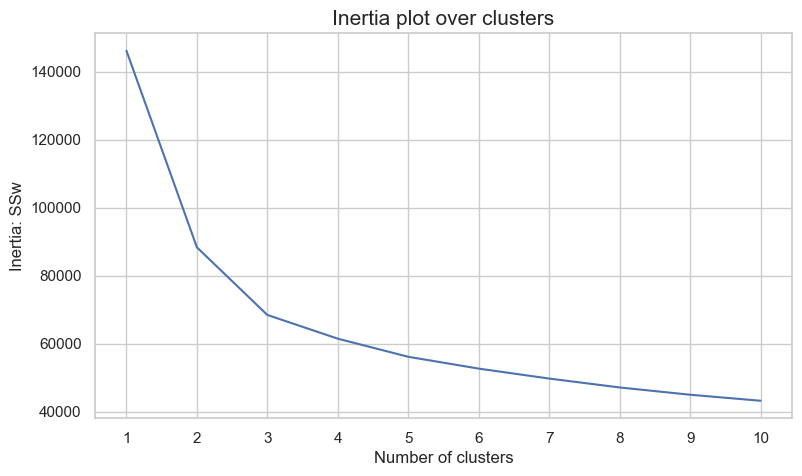

In [55]:
# Behaviour features
range_clusters = range(1,11)

inertia = []
for n_clus in range_clusters:  # iterate over desired ncluster range
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df_beh)
    inertia.append(kmclust.inertia_)


fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In this __inertia plot__, the __elbow__ appeared between 2 and 5 clusters, so __3 clusters__ were chosen as the optimal number for the analysis.

##### Applying K-Means Clustering

In [56]:
kmclust = KMeans(n_clusters=3, init='random', n_init=10, random_state=1)
kmclust

,n_clusters,3
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [57]:
kmclust.fit(df_beh)

,n_clusters,3
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [58]:
kmclust.predict(df_beh)

array([2, 2, 1, ..., 2, 0, 0], shape=(16321,), dtype=int32)

In [59]:
pd.DataFrame(kmclust.transform(df_beh))

,0,1,2
0,6.39814,3.15316,1.42840
1,7.25104,4.66336,2.46616
2,5.19745,1.78765,2.01838
3,6.65297,3.51715,1.49600
4,6.38750,3.22722,1.90394
...,...,...,...
16316,6.50524,3.04829,0.96736
16317,0.31598,4.62058,6.62993
16318,5.83949,2.96456,1.33078
16319,0.31598,4.62058,6.62993


Since the segmentation was based exclusively on numerical variables, __K-Means__ was initially applied as an exploratory tool to obtain a preliminary understanding of potential cluster structures in the data. This initial application was not intended as part of the formal methodological comparison, but rather as a diagnostic step to assess whether meaningful segmentation patterns were present.

## 6. Clustering methods: Hierarchical Clustering

For __clustering methods__, we first applied __hierarchical clustering__.

This method groups similar data points into clusters without needing to predefine the number of clusters. It builds a hierarchy of clusters, represented as a tree-like structure called a __dendrogram__, and can be __agglomerative__ (merging points into clusters) or __divisive__ (splitting a single cluster).

 __Hierarchical clustering__ is useful for exploring the natural structure of data and is widely applied in marketing, such as segmenting customers based on behavior or preferences.

We compared different __linkage methods__ (Ward, complete, average, and single), to see how they affect cluster formation.This analysis was performed for each perspective: demographical and behavioral, to understand how different types of data influence the resulting clusters.



### 6.1. Demographic perspective

First, we will implement this for __demographical Features__.

#### 6.1.1. Defining Best Linkage Method

To determine the best __linkage method__, we will compare the results of __Ward__, __complete__, __average__, and __single__ linkage for the __demographical perspective__. This will help identify which method produces the most distinct and meaningful customer segments for our marketing analysis.

We utilized the optimal number of clusters (k=3), previously derived from the __K-Means__, as the input parameter for our __Hierarchical Clustering__ model. This approach serves as a robustness check, leveraging the mathematical similarities between __K-Means__ and __Ward’s__ linkage. By fixing k=3, we were able to isolate the effect of the linkage criterion, allowing us to compare __Ward’s__ method against other linkages (e.g., Average, Complete) to confirm that the identified customer segments remain stable regardless of the algorithmic approach used.

##### Applying Hierarchical Clustering with ward linkage and with euclidean distance with 3 clusters

In [60]:
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=3)
hc_labels = hclust.fit_predict(df_dem)
hc_labels

array([0, 0, 0, ..., 2, 2, 2], shape=(16321,))

In [61]:
labels_series = pd.Series(hc_labels, 
                          name='labels', 
                          index=df_dem.index 
                          ) 
df_dem = pd.concat(
    [df_dem, labels_series],
    axis=1)
df_dem

,Income,Customer Lifetime Value,ProgramDaysDuration,TotalFlights,TotalPointsRedeemed,labels
0,1.06797,-0.64205,-0.19897,0.58979,0.58684,0
1,-1.24409,-0.64197,-0.22995,1.70478,1.63325,0
2,-1.24409,-0.64195,0.61922,-0.26504,-0.35403,0
3,-1.24409,-0.64195,1.34164,0.66412,0.91617,0
4,1.98051,-0.64147,0.47417,0.35440,-0.99541,0
...,...,...,...,...,...,...
16877,-0.51935,4.43724,0.83890,0.57740,0.75527,2
16882,-1.24409,4.43724,0.95297,-1.75170,-0.99541,2
16891,-1.24409,4.43724,0.02916,0.70128,-0.44899,2
16894,0.77709,4.43724,0.34461,-1.75170,-0.99541,2


In [62]:
df_dem[demographic_features+['labels']].groupby('labels').mean()

,Income,Customer Lifetime Value,ProgramDaysDuration,TotalFlights,TotalPointsRedeemed
labels,,,,,
0,0.08307,-0.29372,0.38801,0.60214,0.36789
1,-0.08875,-0.33091,-0.75504,-1.12994,-0.69102
2,-0.21111,1.74611,0.04547,-0.11086,-0.17932


##### Calculating SSb, SSw and SSt

To quantitatively evaluate the quality of the partition, we performed a decomposition of the __total variance (SST)__. We calculated the __Within Cluster Sum of Squares (SSW)__ to assess the compactness of the clusters, and the __Between Cluster Sum of Squares (SSB)__ to measure the level of separation between them.

In [63]:

def get_ss(df, feats):
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    
    return ss 


def get_ssb(df, feats, label_col):  
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))) )

    ssb = np.sum(ssb_i)    

    return ssb


def get_ssw(df, feats, label_col):
    feats_label = feats+[label_col]

    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats), 
        include_groups=False
        )

    return df_k.sum()

In [64]:
target_col = 'labels'
df_sst_ = get_ss(df_dem, demographic_features)
df_ssb_ = get_ssb(df_dem, demographic_features, target_col)
df_ssw_ = get_ssw(df_dem, demographic_features, target_col)


print("SSb:  ", df_ssb_)
print("SSw:  ", df_ssw_)
print("SSt:  ", df_sst_)
print("SSt == SSb+SSw ? ", (round(df_sst_)) == round((df_ssb_ + df_ssw_)))

SSb:   24861.117492755016
SSw:   51655.87702389773
SSt:   76516.99451665276
SSt == SSb+SSw ?  True


<!-- The variance decomposition confirms the mathematical validity of the solution with high precision. The __SST__ (SST $\approx 76517.0$) is perfectly reconstructed by the __SSB__ (SSB $\approx 24861.1$) and the __SSW__ (SSW $\approx 5655.9$). This exact additivity confirms that the clustering partition is statistically robust and that no variance was lost during the computation. -->

##### Calculating $R^2$

The $R^2$ measures how well a clustering structure explains the variation in the data. <br>
It represents the proportion of total variance explained by the **separation** between clusters: higher values indicate **more distinct** and internally cohesive clusters.

It is based on: 
$$
SS_t = SS_w + SS_b 
$$
and
$$
SS_b = SS_t - SS_w
$$
So, we have: 
$$R^2 = \cfrac{SS_b}{SS_t}$$or$$R^2 = \cfrac{SS_t - SS_w}{SS_t}$$

In [65]:
def get_rsq(df, feats, label_col):


    df_sst_ = get_ss(df, feats)                 # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)     # get ss within
    df_ssb_ = df_sst_ - df_ssw_                 # get ss between

    # r2 = ssb/sst 
    return (df_ssb_/df_sst_)
print(get_rsq(df_dem, demographic_features, 'labels'))

0.32490974913219295


This result indicates that __32.49%__ of the total variation in the dataset is explained by the separation into these __3__ clusters. In the context of customer segmentation, this represents a moderate fit: it confirms that distinct __demographic__ groups exist, but the remaining variance ($\approx  67.5%$) shows that customers from diferent clusters still retain individual differences.

##### Function to compute the $R^2$ for a set of different cluster solutions with a given linkage method

In [66]:
def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    r2 = []  # where we will store the R2 metrics for each cluster solution
    feats = df.columns.tolist()
    
    for i in range(min_nclus, max_nclus+1): 
        
    
        cluster = AgglomerativeClustering(linkage=link_method, metric=dist, n_clusters=i)
        
       
        hclabels = cluster.fit_predict(df[feats])
        
       
        df_concat = pd.concat([df, pd.Series(hclabels, name='labels', index=df.index)], axis=1)  
        
        
        
        r2.append(get_rsq(df_concat, feats, 'labels'))
        
    return np.array(r2)

##### What will be the shape of  $R^2$?

In [67]:
hc_methods = ["ward", "complete", "average", "single"]
max_nclus = 10

results = []
for link in hc_methods:
    r2 = get_r2_hc(
        df=df_dem[demographic_features], 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

In [68]:
r2_hc.shape

(4, 10)

In [69]:
r2_hc_methods = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods)

r2_hc_methods


,ward,complete,average,single
1,0.00000,0.00000,0.00000,0.00000
2,0.22078,0.08857,0.06538,0.00019
3,0.32491,0.23511,0.07828,0.00073
4,0.41454,0.26002,0.32564,0.00095
5,0.46462,0.36825,0.32632,0.00124
6,0.50835,0.37557,0.33036,0.00148
7,0.54079,0.39808,0.38116,0.00162
8,0.56942,0.50449,0.38413,0.00176
9,0.59484,0.51184,0.41893,0.00201
10,0.60993,0.55879,0.42950,0.00219


From the table, we can see that __Ward__ and __complete__ linkage produce steadily increasing distances, indicating well separated clusters. __Average__ linkage shows moderate separation, with distances rising more noticeably in the later merges. In contrast, __single__ linkage maintains very small distances until the final merges, suggesting that clusters are not clearly separated and tend to form elongated chains. Based on this, __Ward__ linkage is expected to produce the most distinct __demographical segments__.

##### Plot of the various hierachical methods

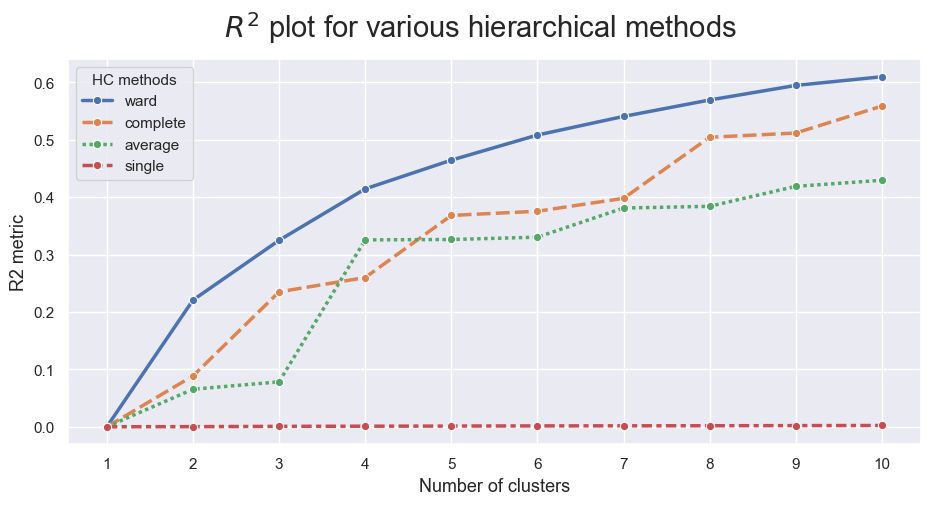

In [70]:
sns.set()

# Plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"]*4)

# Finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods", fontsize=21)

plt.show()

From the __R²__ plot, we can observe that:
*  __Ward__ linkage(blue line) consistently achieves the highest __R²__ values for every number os clusters, indicating that it explains the variance in the data better than the other methods. 
* In contrast, __Single__ Linkage (red line) fails completely (flatlining near zero).
* __Complete__ Linkage (orange line) follows as a respectable second best option, showing stable performance but consistently explaining less variance than __Ward__. 
* Meanwhile, __Average__ Linkage (green line) shows instability, performing poorly. 
* Based on this, __Ward__ linkage is expected to provide the most meaningful and distinct __demographical segments__ for our analysis.

#### 6.1.2. Dendrogram

After evaluating the linkage methods using __R²__, we will now create a __dendrogram__ to visually represent the __hierarchical clustering__ of our data. The __dendrogram__ will allow us to see how __demographical segments__ are formed at different levels of similarity and to decide on an appropriate number of clusters for our analysis. This visual representation complements the __R²__ analysis by showing the structure and relationships between clusters.

##### Linkage Matrix

To generate the __dendrogram__, we first compute a __linkage matrix__, which contains the distances at which clusters are merged and the pairs of clusters combined at each step. The __linkage matrix__ is the foundation for __hierarchical clustering__, as it encodes the hierarchical relationships between data points and allows us to construct the __dendrogram__ to visualize the formation of __demographical segments__.

In [71]:
# setting distance_threshold=0 and n_clusters=None ensures we compute the full tree
linkage = 'ward' 
distance = 'euclidean'
n_clusters = None 

hclust = AgglomerativeClustering(linkage=linkage, metric=distance, n_clusters=n_clusters, distance_threshold=0)
hclust.fit_predict(df_dem[demographic_features])

array([16241,  9241, 15560, ...,     3,     1,     0], shape=(16321,))

In [72]:
# create the counts of samples under each node (number of points being merged)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

# hclust.children_ contains the observation ids that are being merged together
# At the i-th iteration, children[i][0] and children[i][1] are merged to form node n_samples + i
for i, merge in enumerate(hclust.children_):
    # track the number of observations in the current cluster being formed
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            # If this is True, then we are merging an observation
            current_count += 1  # leaf node
        else:
            # Otherwise, we are merging a previously formed cluster
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

# the hclust.children_ is used to indicate the two points/clusters being merged (dendrogram's u-joins)
# the hclust.distances_ indicates the distance between the two points/clusters (height of the u-joins)
# the counts indicate the number of points being merged (dendrogram's x-axis)
linkage_matrix = np.column_stack(
    [hclust.children_, hclust.distances_, counts]
).astype(float)

In [73]:
linkage_matrix.shape

(16320, 4)

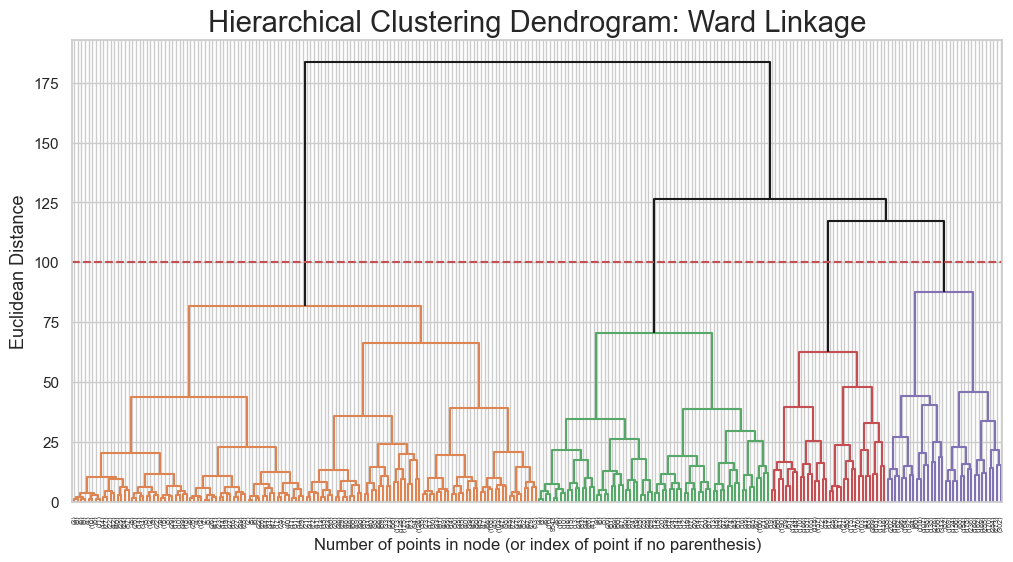

In [74]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
Y_THRESHOLD = 100

dend = dendrogram(
    linkage_matrix,
    truncate_mode='level', 
    p=7,
    color_threshold=Y_THRESHOLD, 
    above_threshold_color='k'   
)

plt.axhline(y=Y_THRESHOLD, color='r', linestyle='--', label=f'Corte para Clusters')

plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'{distance.title()} Distance', fontsize=13)
plt.show()

From the __dendrogram__, it is observed that the data naturally separates into 3 main clusters for the __demographical perspective__. This is justified by the relatively large increase in the linkage distance after the third merge, indicating that combining more clusters would group dissimilar segments together. Therefore, selecting 3 clusters provides a meaningful and well separated segmentation of customers.

##### Final Hierarchical Clustering solution

Based on the __R²__ analysis and __dendrogram__ observations, we selected __Ward__ linkage and __3__ clusters as the final __hierarchical clustering__ solution for the __demographical perspective__.

In [75]:
linkage = "ward" 
distance = "euclidean" 
n_clusters = 3 
hclust = AgglomerativeClustering(linkage=linkage, metric=distance, n_clusters=n_clusters)

hc_labels = hclust.fit_predict(df_dem[demographic_features])

In [76]:
df_concat = pd.concat([
    df_dem[demographic_features], 
    pd.Series(hc_labels, name='labels', index=df_out.index)
    ], 
    axis=1)
df_concat.groupby('labels').mean().T

labels,0,1,2
Income,0.08307,-0.08875,-0.21111
Customer Lifetime Value,-0.29372,-0.33091,1.74611
ProgramDaysDuration,0.38801,-0.75504,0.04547
TotalFlights,0.60214,-1.12994,-0.11086
TotalPointsRedeemed,0.36789,-0.69102,-0.17932


The final hierarchical clustering solution reveals distinct __demographical segments__:
* __Cluster 0:__ 
  - This segment exhibit the highest engagement in `TotalFlights` (0.60) and `TotalPointsRedeemed` (0.37) and have the longest Program Duration (0.39). However, their `Customer Lifetime Value` (CLV) is below average (-0.29). 
  - These are frequent flyers who know how to work the system. They fly often and use the rewards program constantly, but they aren't the most profitable for the airline. This is likely because they buy cheaper tickets (like economy) or use their points to get free flights instead of paying cash.
* __Cluster 1:__
  - This cluster is characterized by significantly below average values across all key metrics. They have the lowest `TotalFlights` value (-1.13), `TotalPointsRedeemed` (-0.69), and `ProgramDaysDuration` (-0.76). 
  - The most probable explanation is that these are brand new customers. We can tell this because their `ProgramDaysDuration` is very low, meaning they joined the airline recently. Since they just arrived, they haven't had enough time to fly often or gain points.
* __Cluster 2:__
  - This is the most financially critical segment, defined almost exclusively by the largest `Customer Lifetime Value` (1.75), nearly two standard deviations above the mean. Meanwhile, their flight frequency (-0.11) and `Income` (-0.21) are slightly below average.
  - This suggests a group where members fly less often but generate massive value because they choose expensive options. Instead of flying frequently on cheap tickets, they likely purchase premium seats (like Business Class) or high value services, meaning they spend more in a single trip than other customers do in ten.

#### 6.1.3 Visualize the cluster means with the cluster sizes

After defining the final __hierarchical clustering__ solution, we implemented visualizations to better understand the characteristics and differences between the 3 demographical clusters.

In [77]:
pop_mean = df_dem[demographic_features].mean()
hc_profile = df_concat.groupby('labels').mean().T
df_concat_pop = pd.concat([hc_profile, 
                           pd.Series(pop_mean, 
                                        index=hc_profile.index, 
                                        name='Population Mean'
                            )
                           ],
                           axis=1)

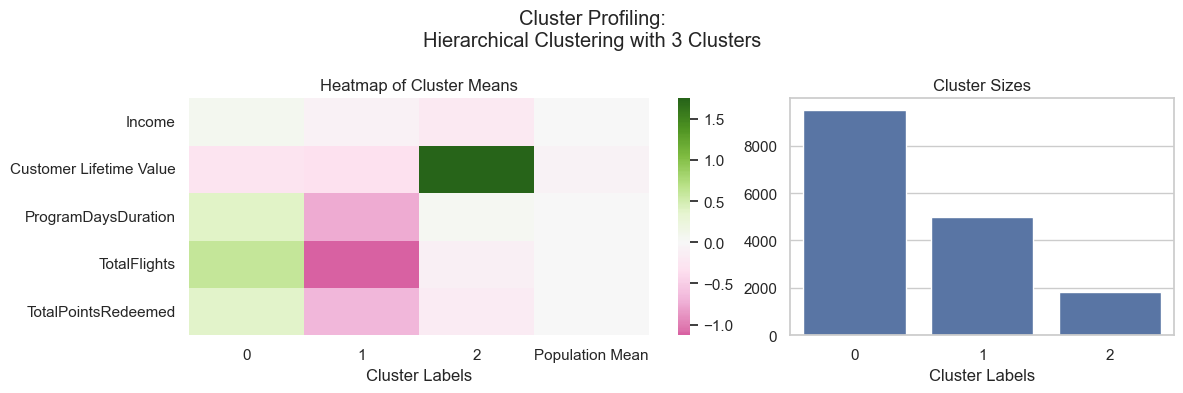

In [78]:
sns.set(style="whitegrid")
label_counts = df_concat['labels'].value_counts().sort_index()

fig, axes = plt.subplots(1,2, figsize=(12,4), width_ratios=[.6,.4], tight_layout=True)

sns.heatmap(df_concat_pop, ax=axes[0], center=0, cmap='PiYG')

axes[0].set_xlabel("Cluster Labels")
axes[0].set_title("Heatmap of Cluster Means")


sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[1])
axes[1].set_title("Cluster Sizes")
axes[1].set_xlabel("Cluster Labels")

fig.suptitle("Cluster Profiling:\nHierarchical Clustering with 3 Clusters")
plt.show()

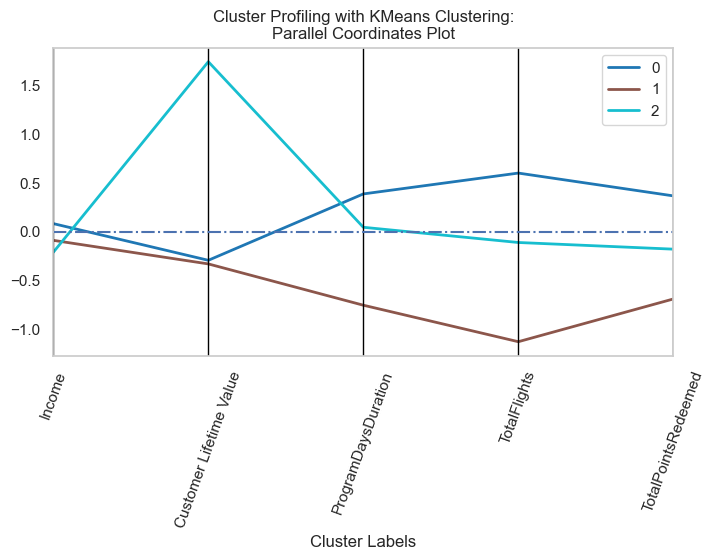

In [79]:
km_profile2 = hc_profile.T.reset_index()
km_profile2['labels'] = km_profile2['labels'].astype(str)

fig, ax = plt.subplots(figsize=(8,4))

parallel_coordinates(km_profile2, 'labels', colormap='tab10', linewidth=2, ax=ax)
ax.set_title('Parallel Coordinates Plot of Cluster Mean Profiles')
ax.axhline(0, linestyle='-.')

ax.set_xlabel("Cluster Labels")


ax.set_title("Cluster Profiling with KMeans Clustering:\nParallel Coordinates Plot")
plt.xticks(rotation=70)
plt.show()

These plots confirm the patterns observed previously and making the distinctions between clusters easier to interpret visually.

### 6.2. Behaviour perspective

Now we will implement for __behaviour perspective__.

#### 6.2.1. Defining Best Linkage Method

Using the same method as before, __linkage method__, to compare the results betweeen __Ward__, __complete__, __average__, and __single__ for the __behaviour perspective__.

We utilized the optimal number of clusters (k=3), previously derived from the __K-Means__, as the input parameter for our __Hierarchical Clustering__ model. This approach serves as a robustness check, leveraging the mathematical similarities between __K-Means__ and __Ward’s__ linkage.

##### Applying Hierarchical Clustering with ward linkage and with euclidean distance with 3 clusters

In [80]:
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=3)
hc_labels = hclust.fit_predict(df_beh)
hc_labels

array([0, 0, 0, ..., 0, 2, 2], shape=(16321,))

In [81]:
labels_series = pd.Series(hc_labels, 
                          name='labels', 
                          index=df_out.index 
                          ) 
df_beh = pd.concat(
    [df_beh, labels_series],
    axis=1)
df_beh

,Flights_Summer,Flights_Spring,Flights_Winter,Flights_Fall,TotalFlightsWithCompanions,PointsRatio,SoloFlightRatio,MaxFlightsInMonth,MaxPointsInMonth,labels
0,1.23172,0.54478,-0.57511,0.29764,0.88506,0.00107,-0.49461,0.09267,0.41247,0
1,1.23172,2.09574,1.00237,1.16760,-0.14355,0.97558,0.92849,0.27567,0.26553,0
2,-0.78860,0.21826,-0.01835,-0.11444,0.15646,-0.13669,-0.78326,-0.45633,0.07977,0
3,-0.28352,1.40189,0.81679,0.48079,0.97078,0.58849,-0.51618,0.09267,0.09456,0
4,0.88448,-0.18988,0.30642,-0.02286,1.14221,-0.99962,-1.06693,0.45867,-0.08011,0
...,...,...,...,...,...,...,...,...,...,...
16877,0.56881,0.09582,0.63120,0.61815,0.62791,0.61836,-0.28849,-0.09033,0.84868,0
16882,-1.41995,-1.33270,-1.41025,-1.48805,-1.51502,-0.99962,1.83802,-2.65233,-2.68347,2
16891,0.78978,0.05500,0.90958,0.48079,0.02789,-0.52795,0.37325,-0.09033,0.40693,0
16894,-1.41995,-1.33270,-1.41025,-1.48805,-1.51502,-0.99962,1.83802,-2.65233,-2.68347,2


In [82]:
df_beh[behaviour_features+['labels']].groupby('labels').mean()

,Flights_Summer,Flights_Spring,Flights_Winter,Flights_Fall,TotalFlightsWithCompanions,PointsRatio,SoloFlightRatio,MaxFlightsInMonth,MaxPointsInMonth
labels,,,,,,,,,
0,0.43066,0.42544,0.41607,0.41677,0.45513,0.11381,-0.17673,0.40448,0.40033
1,-0.99075,-1.01120,-0.94453,-0.89448,-1.05611,-0.02892,-0.16389,-0.29190,-0.25493
2,-1.41995,-1.33270,-1.40957,-1.48789,-1.51502,-0.99962,1.83802,-2.64964,-2.68193


##### Calculating SSb, SSw and SSt

In [83]:
target_col = 'labels'
df_sst_ = get_ss(df_beh, behaviour_features)
df_ssb_ = get_ssb(df_beh, behaviour_features, target_col)
df_ssw_ = get_ssw(df_beh, behaviour_features, target_col)


print("SSb:  ", df_ssb_)
print("SSw:  ", df_ssw_)
print("SSt:  ", df_sst_)
print("SSt == SSb+SSw ? ", (round(df_sst_)) == round((df_ssb_ + df_ssw_)))

SSb:   73560.55384794438
SSw:   72545.86751322566
SSt:   146106.42136117004
SSt == SSb+SSw ?  True


The SST (__SST__ $\approx 146106.4$) is perfectly reconstructed by the __SSB__ (__SSb__ $\approx 73560.55$) and the SSW (__SSw__ $\approx 72545.87$). This exact additivity confirms that the clustering partition is statistically robust and that no variance was lost during the computation.


##### Calculating $R^2$

In [84]:
print(get_rsq(df_beh, behaviour_features, 'labels'))

0.5034724221059745


This result indicates that __50.34%__ of the total variation in the dataset is explained by the separation into these __3__ clusters. In the context of customer segmentation, this represents a balanced fit: it confirms that distinct groups exist with significant structural differences, while the remaining variance ($ \approx 49.66%$) shows that individuals within those clusters still retain a high degree of personal diversity.

##### What will be the shape of  $R^2$?

In [85]:
hc_methods = ["ward", "complete", "average", "single"]
max_nclus = 10

results = []
for link in hc_methods:
    r2 = get_r2_hc(
        df=df_beh[behaviour_features], 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

In [86]:
r2_hc.shape

(4, 10)

In [87]:
r2_hc_methods = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods)

r2_hc_methods


,ward,complete,average,single
1,0.00000,0.00000,0.00000,0.00000
2,0.38345,0.37907,0.35783,0.00008
3,0.50347,0.43779,0.51659,0.00021
4,0.54147,0.47070,0.51669,0.00028
5,0.57296,0.49227,0.51689,0.00037
6,0.59738,0.52754,0.51711,0.00046
7,0.61605,0.53184,0.54409,0.00058
8,0.63263,0.54519,0.54709,0.00071
9,0.64694,0.63303,0.54730,0.00081
10,0.65779,0.64088,0.54878,0.00091


From the table, we can see that __Ward__ and __Complete__ linkage produce steadily increasing distances, indicating well-separated clusters with __Ward__ specifically showing the strongest growth in variance explanation. __Average__ linkage shows moderate separation, with distances rising more noticeably in the middle merges before plateauing slightly. In contrast, __Singl__e linkage maintains extremely small distances ($<0.001$) throughout almost the entire process, suggesting that clusters are not clearly separated and are suffering from the "chaining effect." Based on this, __Ward__ linkage is expected to produce the most distinct in __behaviour segments__, as it maximizes the $R^2$ value to 50.35% at the 3-cluster mark.

##### Plot of the various hierachical methods

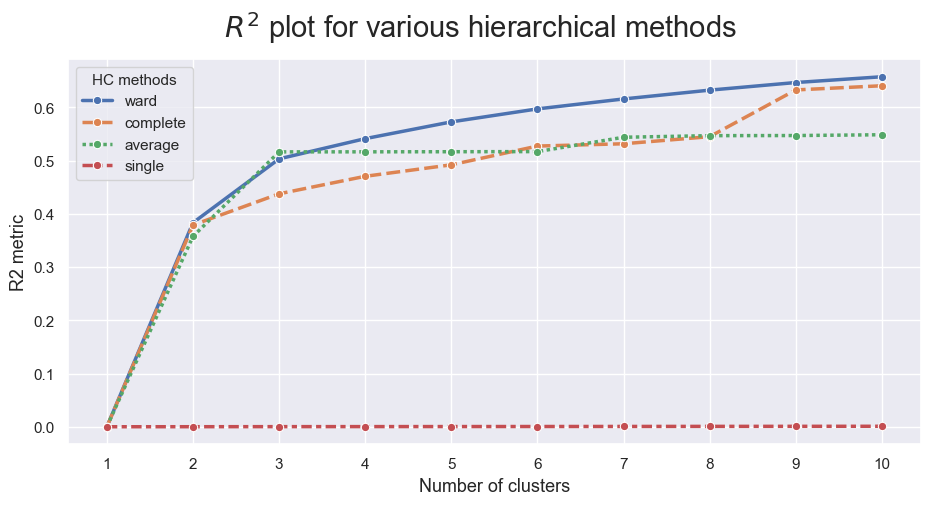

In [88]:
sns.set()

# Plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"]*4)

# Finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods", fontsize=21)

plt.show()


From the __R²__ plot and the corresponding metric table, we can observe that:
* __Ward__ linkage (blue line) consistently achieves the highest __R²__ values for every number of clusters, reaching almost 0.6 at three clusters, indicating that it explains the variance in the data better than the other methods.
* In contrast, __Single__ Linkage (red line) fails completely, flatlining near zero with values as low as 0.00021.
* __Complete__ Linkage (orange line) follows as a respectable second best option, showing stable performance but consistently explaining less variance than __Ward__.
* Meanwhile, __Average__ Linkage (green line) shows instability, with it's performance plateuing early around 0.5 and showing little improvement as more clusters are added.
* Based on this, __Ward__ linkage is expected to provide the most meaningful and distinct demographical segments for our analysis.


#### 6.2.2. Dendrogram

##### Linkage Matrix

In [89]:
# setting distance_threshold=0 and n_clusters=None ensures we compute the full tree
linkage = 'ward' 
distance = 'euclidean'
n_clusters = None 

hclust = AgglomerativeClustering(linkage=linkage, metric=distance, n_clusters=n_clusters, distance_threshold=0)
hclust.fit_predict(df_beh[behaviour_features])

array([ 9774, 10598, 12296, ...,     1,     2,     0], shape=(16321,))

In [90]:
# create the counts of samples under each node (number of points being merged)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

# hclust.children_ contains the observation ids that are being merged together
# At the i-th iteration, children[i][0] and children[i][1] are merged to form node n_samples + i
for i, merge in enumerate(hclust.children_):
    # track the number of observations in the current cluster being formed
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            # If this is True, then we are merging an observation
            current_count += 1  # leaf node
        else:
            # Otherwise, we are merging a previously formed cluster
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

# the hclust.children_ is used to indicate the two points/clusters being merged (dendrogram's u-joins)
# the hclust.distances_ indicates the distance between the two points/clusters (height of the u-joins)
# the counts indicate the number of points being merged (dendrogram's x-axis)
linkage_matrix = np.column_stack(
    [hclust.children_, hclust.distances_, counts]
).astype(float)

In [91]:
linkage_matrix.shape

(16320, 4)

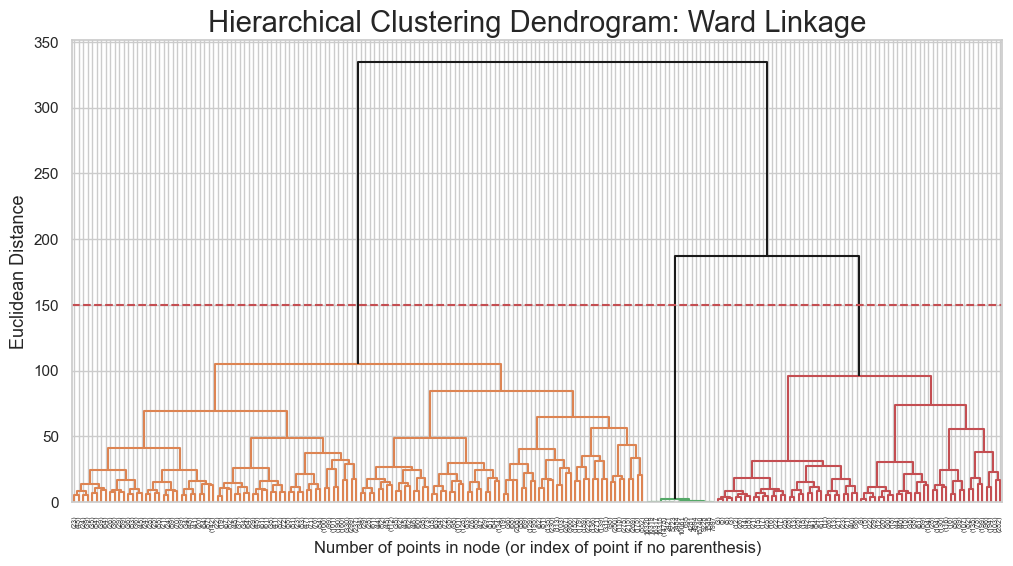

In [92]:
# 3. Configurar o gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
Y_THRESHOLD = 150

dend = dendrogram(
    linkage_matrix,
    truncate_mode='level', 
    p=7,
    color_threshold=Y_THRESHOLD, 
    above_threshold_color='k'   
)

plt.axhline(y=Y_THRESHOLD, color='r', linestyle='--', label=f'Corte para Clusters')

plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'{distance.title()} Distance', fontsize=13)
plt.show()

<!-- From the __dendrogram__, it is observed that the data is divided into 2 main cluster for the __behaviour perpective__. This is justified by the relatively large increase in the linkage distance after the second merge, represented by the significant vertical gap before the final branches join. Such a "jump" in the y-axis (Euclidean Distance) indicates that combining these groups further would merge highly dissimilar segments together. -->

##### Final Hierarchical Clustering solution

Based on the __R²__ analysis and __dendrogram__ observations, we selected __Ward__ linkage and __2__ clusters as the final __hierarchical clustering__ solution for the __behaviour perspective__.

In [93]:
linkage = "ward" 
distance = "euclidean" 
n_clusters = 2 
hclust = AgglomerativeClustering(linkage=linkage, metric=distance, n_clusters=n_clusters)

hc_labels2 = hclust.fit_predict(df_beh[behaviour_features])

In [94]:
df_concat2 = pd.concat([
    df_beh[behaviour_features], 
    pd.Series(hc_labels2, name='labels', index=df_out.index)
    ], 
    axis=1)
df_concat2.groupby('labels').mean().T

labels,0,1
Flights_Summer,-1.13131,0.43066
Flights_Spring,-1.11648,0.42544
Flights_Winter,-1.09683,0.41607
Flights_Fall,-1.08881,0.41677
TotalFlightsWithCompanions,-1.20640,0.45513
PointsRatio,-0.34681,0.11381
SoloFlightRatio,0.49171,-0.17673
MaxFlightsInMonth,-1.06402,0.40448
MaxPointsInMonth,-1.04974,0.40033


The final __hierarchical clustering__ solution reveals distinct travel behavior segments:

* __Cluster 0__: 
    - This segment is characterized by significantly below-average values across all activity metrics, including `TotalFlightsWithCompanions` (-1.21) and `MaxFlightsInMonth` (-1.06). They also exhibit the lowest seasonal flight counts, such as `Flights_Summer` (-1.13) and `Flights_Spring` (-1.12).
    - These appear to be low-engagement or dormant customers who rarely fly regardless of the season. Interestingly, they have a higher `SoloFlightRatio` (0.49) compared to the other group, suggesting that when they do travel, they are more likely to fly alone rather than with companions.
* __Cluster 1__:
    - This cluster shows consistently high engagement across nearly all flight metrics, with positive values for `Flights_Summer` (0.43) and TotalFlightsWithCompanions (0.46). They also maintain a steady frequency throughout the year, with `Flights_Winter` (0.42) and `Flights_Fall` (0.42) being well above the average.
    - These are your "Steady Travelers" who demonstrate reliable, year-round loyalty to the airline. While they fly more frequently and earn more points—indicated by a positive `MaxPointsInMonth` (0.40)—they have a lower `SoloFlightRatio` (-0.18), meaning their travel is often social or family-oriented rather than individual.

#### 6.1.3 Visualize the cluster means with the cluster sizes

After defining the final __hierarchical clustering__ solution, we implemented visualizations to better understand the characteristics and differences between the 2 demographical clusters.

In [95]:
pop_mean = df_beh[behaviour_features].mean()
hc_profile2 = df_concat2.groupby('labels').mean().T
df_concat_pop = pd.concat([hc_profile2, 
                           pd.Series(pop_mean, 
                                        index=hc_profile2.index, 
                                        name='Population Mean'
                            )
                           ],
                           axis=1)

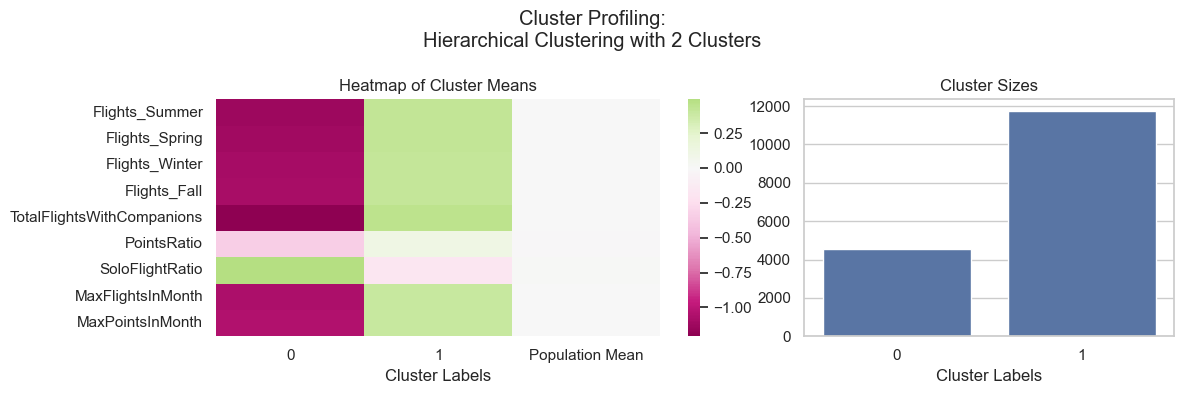

In [96]:
sns.set(style="whitegrid")
label_counts = df_concat2['labels'].value_counts().sort_index()

fig, axes = plt.subplots(1,2, figsize=(12,4), width_ratios=[.6,.4], tight_layout=True)

sns.heatmap(df_concat_pop, ax=axes[0], center=0, cmap='PiYG')

axes[0].set_xlabel("Cluster Labels")
axes[0].set_title("Heatmap of Cluster Means")


sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[1])
axes[1].set_title("Cluster Sizes")
axes[1].set_xlabel("Cluster Labels")

fig.suptitle("Cluster Profiling:\nHierarchical Clustering with 2 Clusters")
plt.show()

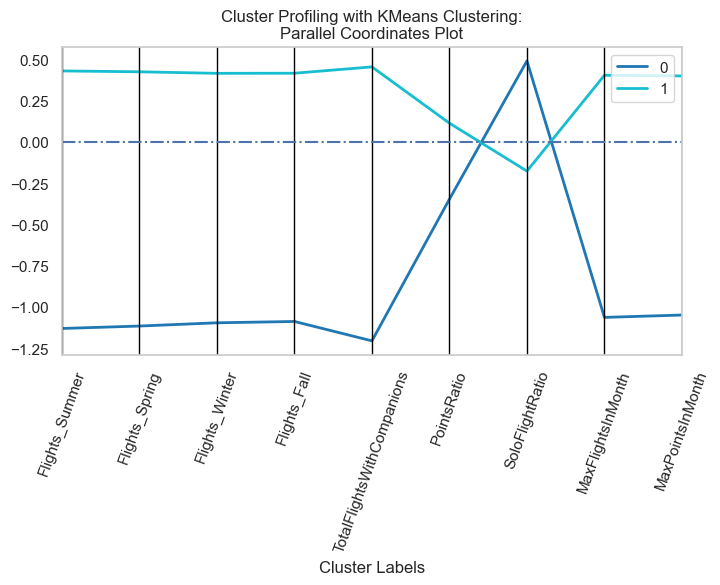

In [97]:
km_profile2 = hc_profile2.T.reset_index()
km_profile2['labels'] = km_profile2['labels'].astype(str)

fig, ax = plt.subplots(figsize=(8,4))

parallel_coordinates(km_profile2, 'labels', colormap='tab10', linewidth=2, ax=ax)
ax.set_title('Parallel Coordinates Plot of Cluster Mean Profiles')
ax.axhline(0, linestyle='-.')

ax.set_xlabel("Cluster Labels")


ax.set_title("Cluster Profiling with KMeans Clustering:\nParallel Coordinates Plot")
plt.xticks(rotation=70)
plt.show()

These plots confirm the patterns observed previously and making the distinctions between clusters easier to interpret visually.

## 7. Clustering methods: Self-organizing maps

To complement the partition based and __hierarchical__ clustering approaches, we implemented a __Self-Organizing Map (SOM)__. Unlike the previous algorithms, __SOM__ is a type of Unsupervised Artificial __Neural Network__. Its primary objective is dimensionality reduction: it transforms complex, high dimensional input data (our multiple customer attributes) into a discrete, low dimensional map.

##### Helper functions for SOM 

In [98]:
## SOM Visualization Helpers

def get_index_matrix(nx, ny):
    # Given nx=2, ny=3
    # This will return a matrix whose contents are the index values:
    # 
    # (0,0) (0,1) (0,2)
    # (1,0) (1,1) (1,2)

    x = np.linspace(0, nx-1, nx)
    y = np.linspace(0, ny-1, ny)
    xv, yv = np.meshgrid(x, y, indexing='xy')


    mx_index = np.full((nx,ny),str)

    for i, j in zip(xv,yv):    
        for ii, jj  in zip(i,j):
            ii = int(ii)
            jj = int(jj)
            mx_index[ii,jj] = f"({ii},{jj})"

    return mx_index



# Visualize RGB SOM as colored grid

def plot_rgb_matrix(som_matrix, som, ax, annot_mx=None):

    som_x, som_y = som.get_weights().shape[:2]
    
    for i in range(som_x):
        for j in range(som_y):
            # Get RGB color for this unit (ensure values in 0-1 range)
            color = np.clip(som_matrix[i, j], 0, 1)
            
            # Convert grid to hexagonal coordinates
            hex_coord = som.convert_map_to_euclidean((i, j))
            
            center = [hex_coord[0], hex_coord[1]]
            
            # Draw hexagon with learned color
            hexagon = RegularPolygon(
                center, 
                numVertices=6, 
                radius=np.sqrt(1/3),
                facecolor=color, 
                edgecolor='white', 
                linewidth=2
            )
            ax.add_patch(hexagon)
            
            if "None" in str((type(annot_mx))):
                pass 
            else:
                
                annot_val = annot_mx[i,j]
                if "str" in str(type(annot_val)):
                    pass 
                else:
                    if int(annot_val) == annot_val:
                        annot_val = int(annot_val)
                
                ax.text(center[0], center[1], annot_val, 
                        ha='center', va='center',
                        fontsize='x-small')
    

    
    ax.set_xlim(-1, som_x-.5)
    ax.set_ylim(-1, som_y)
    ax.set_aspect('equal')
    ax.axis('off')

    return ax


### 7.1 Demographic perspective

Firstly, we will apply the method for the __demographic perspective__.

In [99]:
som_data = df_out[demographic_features].to_numpy()


In [100]:

sm = MiniSom(
    x=15, y=10,                     
    input_len=len(demographic_features),
    sigma=1.5,                       
    learning_rate=0.1,
    neighborhood_function='gaussian',
    topology='hexagonal',
    random_seed=42
)

##### SOM Quality Metrics
**Quantization Error (QE):** 
- average distance between each data point and its BMU

$$q_e = \frac{\sum_{i=0}^{N_e}||x_i - w_e||}{N_e}$$

$$Q = \frac{\sum_{e=0}^Eq_e}{E}$$

- where:
    - $Q$ is the overall quantization error of SOM,
    - $q_e$ is the quantization error for unit $e$,
    - $x_i$ is a data point/ observation,
    - $w_e$ is the unit $e$ representation in the input space,
    - $N_e$ is number of data points mapped to unit $e$,
    - $E$ is the number of units in the SOM grid
- Data representation measure

<br>
<br>

**Topographic Error (TE):**
- proportion of data points for which first and second BMUs are not adjacent 
    - range [0,1]
- Topology preservation measure 

In [101]:
sm.random_weights_init(som_data) 

qe_before = sm.quantization_error(som_data)
te_before = sm.topographic_error(som_data)

print(f"Quantization Error (QE): {qe_before:.4f}")
print(f"Topographic Error (TE):  {te_before:.4f}")

c:\Users\anard\anaconda3\envs\fall2526\lib\site-packages\minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


Quantization Error (QE): 0.7685
Topographic Error (TE):  0.9787


In [102]:
sm.train_batch(
    som_data, 
    num_iteration=30000, #to have improvement
    verbose=False
    )

In [103]:
qe_after = sm.quantization_error(som_data)
te_after = sm.topographic_error(som_data)

print(f"Quantization Error (QE): {qe_after:.4f}")
print(f"Topographic Error (TE):  {te_after:.4f}")

print(f"QE reduction: {qe_before:.4f} → {qe_after:.4f} ({(1 - qe_after/qe_before)*100:.1f}% improvement)")
print(f"TE reduction: {te_before:.4f} → {te_after:.4f} ({(1 - te_after/te_before)*100:.1f}% improvement)")

Quantization Error (QE): 0.7154
Topographic Error (TE):  0.2368
QE reduction: 0.7685 → 0.7154 (6.9% improvement)
TE reduction: 0.9787 → 0.2368 (75.8% improvement)


The __SOM__ model achieved a significant increase in stability and representational quality.
* The most important result was the big drop in __Topographic Error (TE)__, which went from 0.9787 down to 0.2368 (a 75% improvement). A high score here means the map is 'twisted' and confusing. The new low score proves that the map is now smooth and organized correctly, so customers placed next to each other are actually similar.
* At the same time, the __Quantization Error (QE)__ also got better, dropping from 0.7685 to 0.7154. This simply means the model is now more precise and describes the customers more accurately.
* Since both error numbers went down significantly, we can trust that this model is stable and ready to be used for our analysis.

In [104]:
weights = sm.get_weights()
weights.shape

(15, 10, 5)

In [105]:
print(weights[0, 0])
print(weights[0, 1])

[ 0.98025651 -0.52151181 -0.53778939 -0.04750202 -0.82883981]
[ 1.35046905 -0.22442219 -0.01806078  0.31846786 -0.75305374]


In [106]:
def plot_hexagons(som_matrix, som, sf, 
                  label='', cmap=None, 
                  annot_mx=None):

    som_x, som_y = som.get_weights().shape[:2]
    
    show_cbar = False if "None" in str((type(cmap))) else True
    
    # Normalize the values to [0,1] to calculate color
    colornorm = mpl_colors.Normalize(vmin=np.min(som_matrix), vmax=np.max(som_matrix))
    
    ax = sf.subplots(1,1)

    
    for i in range(som_x):
        for j in range(som_y):
            if "None" in str((type(cmap))):
                # Get RGB color for this unit (ensure values in 0-1 range)
                color = np.clip(som_matrix[i, j], 0, 1)
            else:
                color = cmap(colornorm((som_matrix[i, j])))

            # Convert grid to hexagonal coordinates
            hex_coord = som.convert_map_to_euclidean((i, j))
            
            center = [hex_coord[0], hex_coord[1]]
            
            # Draw hexagon with learned color
            hexagon = RegularPolygon(
                center, 
                numVertices=6, 
                radius=np.sqrt(1/3),
                facecolor=color, 
                edgecolor='white', 
                linewidth=2
            )
            ax.add_patch(hexagon)
            
            if "None" in str((type(annot_mx))):
                pass 
            else:
                
                annot_val = annot_mx[i,j]
                if "str" in str(type(annot_val)):
                    pass 
                else:
                    if int(annot_val) == annot_val:
                        annot_val = int(annot_val)
                
                ax.text(center[0], center[1], annot_val, 
                        ha='center', va='center',
                        fontsize='x-small')
                
            
    
    ax.set_title(label)

    
    ax.set_xlim(-1, som_x)
    ax.set_ylim(-1, som_y)
    ax.set_aspect('equal')
    ax.axis('off')

    if show_cbar:
        ### Add colorbar
        divider = make_axes_locatable(ax)
        ax_cb = divider.append_axes("right", size="5%", pad="0%")

        ## Create a Mappable object for colorbar
        cmap_sm = plt.cm.ScalarMappable(cmap=cmap, norm=colornorm)
        cmap_sm.set_array([])

        ## Create custom colorbar 
        cb1 = colorbar.Colorbar(ax_cb,
                                orientation='vertical', 
                                alpha=1,
                                mappable=cmap_sm
                                )
        cb1.ax.get_yaxis().labelpad = 6

        # Add colorbar to plot
        sf.add_axes(ax_cb)


    return ax

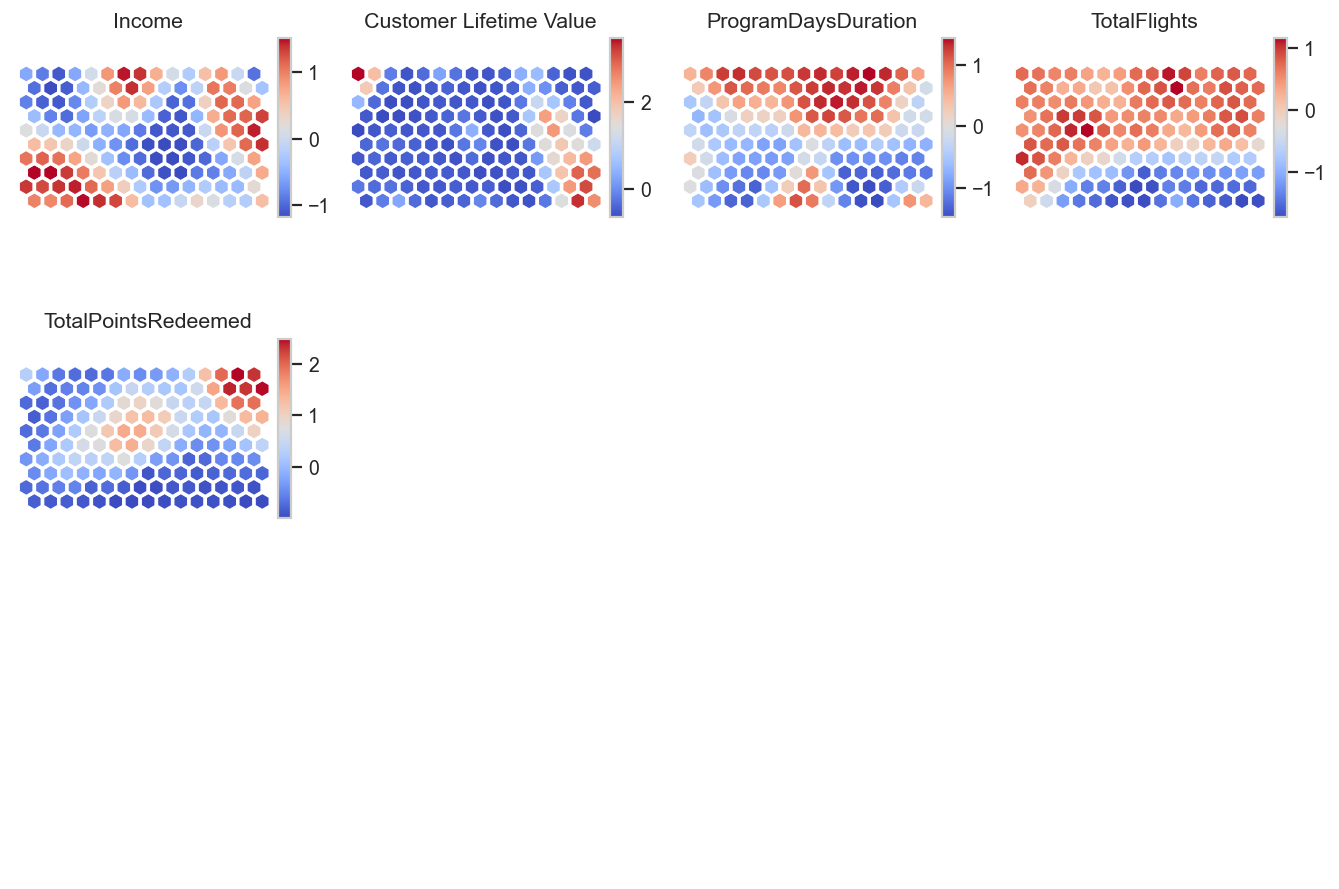

In [107]:
figsize=(9,6)
cmap = cm.coolwarm


fig = plt.figure(figsize=(10,7), constrained_layout=True, dpi=128, )

# Create Sub-figures
subfigs = fig.subfigures(3,4,wspace=.15)

# Plot one Component Plane for each subfigure
for cpi, sf in zip(range(len(demographic_features)), subfigs.flatten()):
    
    # Get the weights of a single component
    matrix_vals = weights[:,:,cpi]


    sf = plot_hexagons(matrix_vals, 
                       sm, sf, 
                       label=metric_features[cpi],      # Add Component Plane title
                       cmap=cmap , annot_mx=None)



plt.show()


* There is a specific red spot in the bottom-right corner for `Customer Lifetime Value`, but that same spot is blue for `TotalFlights`. This proves there is a group of customers who pay a lot of money to the airline but actually take very few trips.
* The map for `ProgramDaysDuration` looks almost exactly like the map for `TotalFlights`. This means that staying with the airline is the main reason people fly. New customers (at the bottom of the map) are almost always inactive.
* On the other hand, while many people fly often (the whole top area is red), only a small corner (top right) actually uses their rewards points. This shows that redeeming points is a special habit of only the most active users.
* In conclusion, the maps confirm the three groups we found earlier.

##### U-Matrix (Unified Distance Matrix)

Shows average **distance** between each SOM unit and its neighbors

Analyse: 
- Clusters of units 
- Potential outliers 

To visualize the structural boundaries within the __Self-Organizing Map__, we generated the __U-Matrix__ (Unified Distance Matrix). While the previously analyzed Component Planes allow for the inspection of individual variables, the __U-Matrix__ provides a holistic view of the geometric distances between the neurons themselves in the high dimensional feature space.


In [108]:
umatrix = sm.distance_map(scaling='mean')

## Flip and rotate to match plot
print(np.flip(np.round(umatrix,2), axis=1).T)

[[1.   0.91 0.44 0.3  0.37 0.46 0.32 0.4  0.42 0.38 0.46 0.52 0.44 0.41
  0.42]
 [0.77 0.79 0.46 0.3  0.37 0.43 0.39 0.36 0.42 0.39 0.46 0.64 0.6  0.46
  0.48]
 [0.52 0.37 0.33 0.35 0.38 0.38 0.38 0.42 0.35 0.36 0.68 0.68 0.59 0.44
  0.39]
 [0.32 0.32 0.33 0.31 0.33 0.37 0.4  0.44 0.4  0.36 0.63 0.85 0.58 0.65
  0.42]
 [0.29 0.32 0.32 0.28 0.35 0.34 0.38 0.49 0.43 0.44 0.75 0.58 0.66 0.62
  0.55]
 [0.26 0.3  0.33 0.34 0.36 0.37 0.36 0.41 0.44 0.41 0.47 0.7  0.55 0.51
  0.59]
 [0.33 0.34 0.37 0.4  0.39 0.42 0.56 0.48 0.38 0.3  0.45 0.65 0.57 0.5
  0.44]
 [0.26 0.32 0.35 0.37 0.38 0.45 0.54 0.62 0.5  0.39 0.27 0.52 0.61 0.54
  0.43]
 [0.34 0.37 0.36 0.31 0.48 0.52 0.44 0.42 0.51 0.33 0.28 0.54 0.75 0.56
  0.42]
 [0.3  0.38 0.47 0.35 0.4  0.56 0.47 0.39 0.45 0.42 0.3  0.36 0.75 0.84
  0.47]]


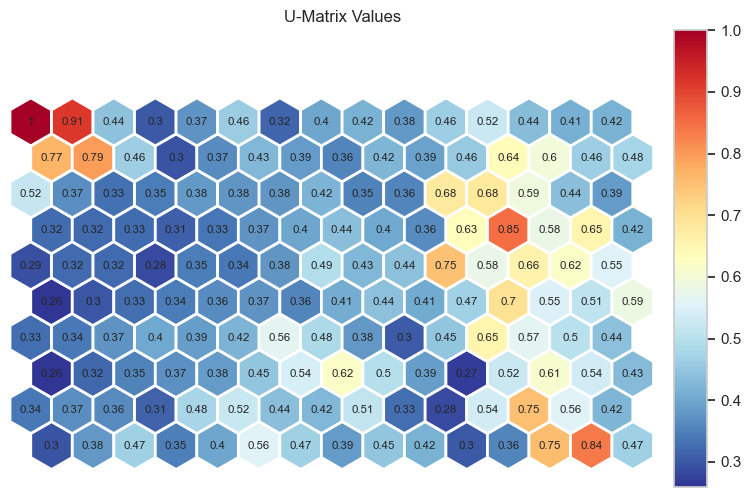

In [109]:
fig = plt.figure(figsize=(9,6))
umx_annot = get_index_matrix(10,10)

plot_hexagons(umatrix,
              sm, fig, 
              label="U-Matrix Values",      # Add Component Plane title
              cmap=cm.RdYlBu_r , 
              annot_mx=np.round(umatrix,2))

plt.show()

The __U-Matrix__ visualization reveals a clear topological separation between the identified customer segments.
* The __dominant feature__ is a large, continuous low distance basin (deep blue, values < 0.35) covering the left side of the map. This confirms that the "low Engagement" segment is highly uniform. Inactive customers tend to be inactive in very similar ways.
* A __distinct vertical barrier of high distances__ (yellow/red, values > 0.65) bisects the map. This 'ridge' effectively acts as a structural wall, statistically isolating the active segments on the right from the inactive mass on the left.
* Finally, the presence of __isolated high distance peaks__ (red hexagons) in the top left and distinct basins in the bottom right confirms that the first 2 groups previously mentioned are not merely extensions of the main population, but are distinct, well separated clusters, with unique statistical properties.

##### Hit-map 

The __Hit Map__ helps us see exactly how the customers are distributed across the different groups( the **frequency** of each Unit in the output map).

In [110]:
hitsmatrix = sm.activation_response(df_out[demographic_features].values)

## Values of HITS:
## Flip and rotate to match plot
np.flip(np.round(hitsmatrix,2), axis=1).T

array([[112., 123., 159., 121., 147., 202., 164., 168., 119., 110.,  80.,
         63.,  81., 106., 181.],
       [122., 144., 146.,  98., 126., 104., 188., 127.,  90., 104.,  69.,
        101.,  97.,  52., 152.],
       [163., 125.,  97.,  79., 162., 116.,  95., 114., 107., 109., 105.,
         68.,  77.,  87., 107.],
       [128.,  65., 131.,  79., 132., 103.,  86., 131., 139., 121., 137.,
         82.,  60.,  95., 113.],
       [105.,  69., 107.,  60., 133.,  68.,  87., 191., 120.,  91., 114.,
         91.,  63.,  78., 141.],
       [128., 106.,  82.,  96.,  98.,  87., 119., 114., 131.,  97., 106.,
         78.,  43.,  46.,  52.],
       [108., 105.,  86., 113., 116.,  86., 109.,  31.,  34., 166., 150.,
        158.,  70.,  25.,  40.],
       [108., 102.,  89.,  99., 136., 190.,  28., 154., 111., 372.,  45.,
        128.,  60.,  44.,  44.],
       [137.,  91.,  90., 124., 168.,  55., 102., 117., 124.,  23., 146.,
        138., 117.,  23.,  13.],
       [ 88., 120., 208., 172., 106.,

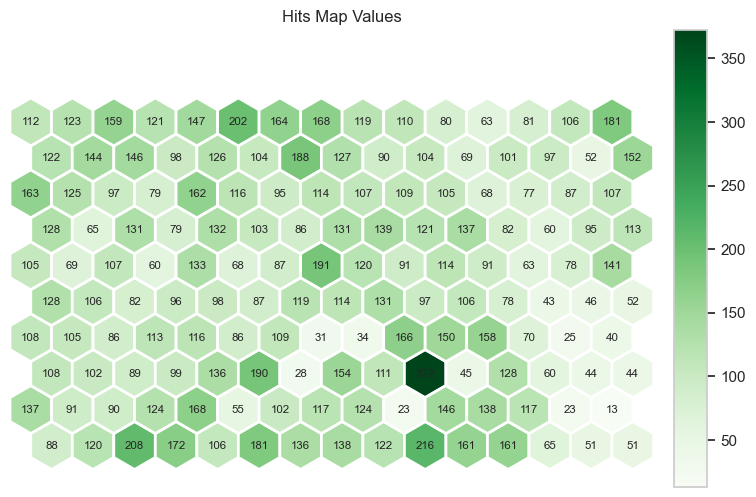

In [111]:
fig = plt.figure(figsize=(9,6))

plot_hexagons(hitsmatrix,
              sm, fig, 
              label="Hits Map Values",
              cmap=cm.Greens , 
              annot_mx=np.round(hitsmatrix,2))

plt.show()

* First, there is a __highly concentrated group__ in the bottom right corner. We see one very dark hexagon containing 372 people. This is the highest number in a single spot. It tells us that this specific group of customers is almost identical to each other; they fit a very strict profile and do not vary much.
* Second, the __largest population__ is found in the top section of the map. This entire area is full of dark green spots with high numbers (between 150 and 200 people each). Unlike the bottom right group, which is packed into one tight spot, these customers are spread out across the top. This means that while there are many of them, they have slightly different habits from one another.
* Finally, the map shows clear __borders__. We can see light green areas with very low numbers (like 13 or 23 people) sitting between the dark spots. These "empty spaces" act like walls, proving that customers usually fall clearly into one specific area instead of being stuck in the middle.

##### SOM K-Means clustering map

This step is crucial because it removes the subjectivity of just looking at the colors. Instead of guessing where one group ends and another begins, we applied the __K-Means__ algorithm to the map itself to draw the final borders between the customer segments.

Reshaped weights_flat shape: (150, 5)
K-Means cluster matrix shape: (15, 10)


<Figure size 1000x600 with 0 Axes>

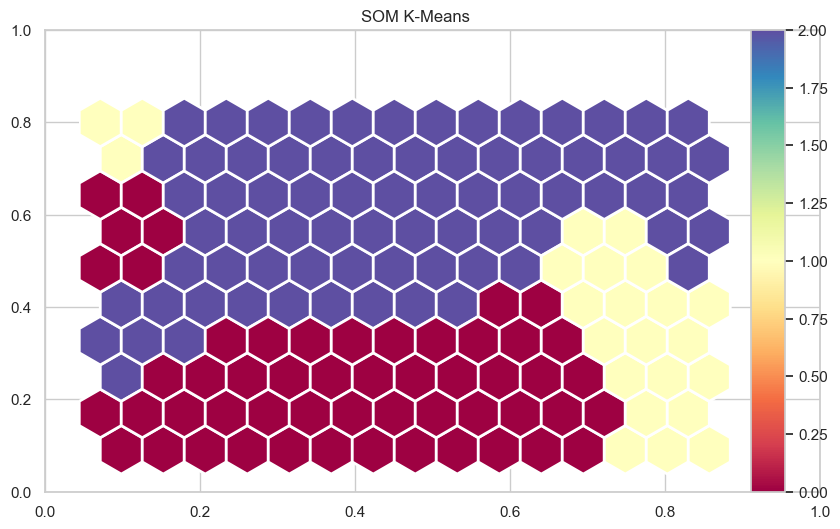

In [112]:
# Ensure df_dem matches the SOM feature size
num_features_som = weights.shape[2]
if len(df_dem.columns) != num_features_som:
    print(f"Warning: df_dem has {len(df_dem.columns)} features, "
          f"but SOM expects {num_features_som}. Selecting first {num_features_som} columns.")
    df_dem = df_dem.iloc[:, :num_features_som]

# Flatten SOM weights for K-Means
weights_flat = weights.reshape((-1, num_features_som))
print(f"Reshaped weights_flat shape: {weights_flat.shape}")

# Apply K-Means clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=20, random_state=42)
nodeclus_labels = kmeans.fit_predict(weights_flat)

# Reshape labels back to SOM grid
som_shape = weights.shape[:2]  # e.g., (15, 10)
kmeans_matrix = nodeclus_labels.reshape(som_shape)
print(f"K-Means cluster matrix shape: {kmeans_matrix.shape}")

# Plot using your existing plot_hexagons function
fig = plt.figure(figsize=(10, 6))  # adjust figsize as needed
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(kmeans_matrix))

fig, ax = plt.subplots(figsize=(10,6))  # create figure/subplot
plot_hexagons(
    kmeans_matrix,   # som_matrix
    sm,              # your SOM object
    fig,             # figure
    label="SOM K-Means",
    cmap=cm.Spectral
)
plt.show()



The __K-Means__ algorithm successfully partitioned the __SOM__ grid into three distinct regions. By comparing these colored zones with our previous analysis in mind, we can clearly identify the three segments:
* Cluster 0:
  - Occupies the bottom left and bottom-center of the map.
  - It represents the Low Engagement customers who have low flight activity, low tenure and low value.
* Cluster 1:
  - Occupies the bottom right section.
  - This clearly isolates the specific "niche" we identified earlier. It captures the High Value Elite customers who generate high revenue (CLV) despite lower flight frequency, distinct from the standard frequent flyers.
* Cluster 2:
  - Occupies the top left and top center of the map.
  - This region aligns perfectly with the high activity areas for `TotalFlights` and `ProgramDaysDuration`. It contains the Loyal Frequent Flyers the active core of the customer base.

The fact that __K-Means__ grouped the neurons into these three specific blocks confirms that the customer segments are topologically distinct. The map does not show a messy mix of customers. Instead, it shows clear, hard borders between the groups. This final validation proves that the __3 cluster__ solution is robust and geometrically stable.
### 7.2. Behaviour perspective

Now, the same was done to the __behaviour perspective__.

In [113]:
som2_data = df_out[behaviour_features].to_numpy()


In [114]:

sm = MiniSom(
    x=15, y=10,                     
    input_len=len(behaviour_features),
    sigma=1.5,                       
    learning_rate=0.1,
    neighborhood_function='gaussian',
    topology='hexagonal',
    random_seed=42
)

##### SOM Quality Metrics


In [115]:
sm.random_weights_init(som2_data) 

qe_before = sm.quantization_error(som2_data)
te_before = sm.topographic_error(som2_data)

print(f"Quantization Error (QE): {qe_before:.4f}")
print(f"Topographic Error (TE):  {te_before:.4f}")

c:\Users\anard\anaconda3\envs\fall2526\lib\site-packages\minisom.py:631: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)


Quantization Error (QE): 1.1792
Topographic Error (TE):  0.9683


In [116]:
sm.train_batch(
    som2_data, 
    num_iteration=30000, #to have improvement
    verbose=False
    )

In [117]:
qe_after = sm.quantization_error(som2_data)
te_after = sm.topographic_error(som2_data)

print(f"Quantization Error (QE): {qe_after:.4f}")
print(f"Topographic Error (TE):  {te_after:.4f}")

print(f"QE reduction: {qe_before:.4f} → {qe_after:.4f} ({(1 - qe_after/qe_before)*100:.1f}% improvement)")
print(f"TE reduction: {te_before:.4f} → {te_after:.4f} ({(1 - te_after/te_before)*100:.1f}% improvement)")

Quantization Error (QE): 1.0688
Topographic Error (TE):  0.1869
QE reduction: 1.1792 → 1.0688 (9.4% improvement)
TE reduction: 0.9683 → 0.1869 (80.7% improvement)


As a beggining the __quantization error__ was $\approx 1.18$ then it improved to $\approx 1.07$, witch indicates that the neurons have moved closer to the actual data points they represent. The "fit" of the map to the data is tighter. <br>
For the __topographic error__ we had an high value, that indicates that the the map is "tangled" or chaotic. Reducing it to $\approx 0.19$ means the model has successfully organized itself so that similar data points are now mapped to adjacent neurons. The "manifold" of the data is now well-represented. <br>
Overall, the training was highly effective. The model has transitioned from a state of random noise to a structured representation of our dataset. 

In [118]:
weights = sm.get_weights()
weights.shape

(15, 10, 9)

In [119]:
print(weights[0, 0])
print(weights[0, 1])

[ 0.68558268  1.07898246  1.40346952  1.4519009   1.56665371 -0.2647953
 -0.44695406  0.49795818  0.52590204]
[ 0.21562395  1.13687104  1.59795499  1.02292384  1.61339006  0.13555754
 -0.67091141  0.47830673  0.43193147]


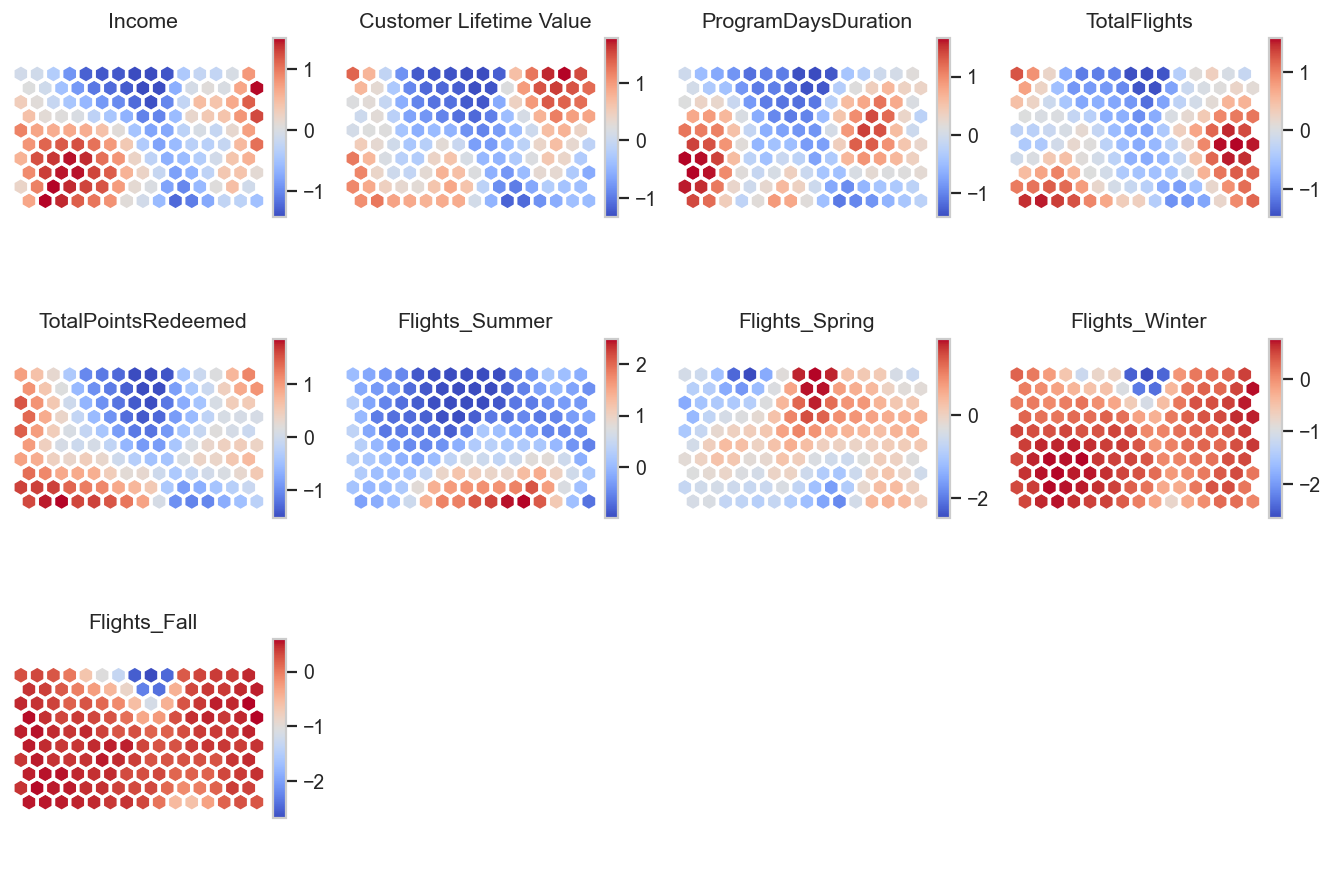

In [120]:
figsize=(9,6)
cmap = cm.coolwarm


fig = plt.figure(figsize=(10,7), constrained_layout=True, dpi=128, )

# Create Sub-figures
subfigs = fig.subfigures(3,4,wspace=.15)

# Plot one Component Plane for each subfigure
for cpi, sf in zip(range(len(behaviour_features)), subfigs.flatten()):
    
    # Get the weights of a single component
    matrix_vals = weights[:,:,cpi]


    sf = plot_hexagons(matrix_vals, 
                       sm, sf, 
                       label=metric_features[cpi],      # Add Component Plane title
                       cmap=cmap , annot_mx=None)



plt.show()


The resulting heatmaps reveal clear behavioral clusters, particularly a strong correlation between `Income` and `TotalPointsRedeemed` in the lower-left region. Seasonality is also evident, as the `Flights_Winter` and `Flights_Fall` maps show nearly identical high-density patterns (red areas) across the bottom of the grid, distinct from spring and summer patterns. Overall, these metrics and visualizations confirm the model has effectively segmented customers based on their lifetime value and flight habits

##### U-Matrix (Unified Distance Matrix)


In [121]:
umatrix = sm.distance_map(scaling='mean')

# Flip and rotate to match plot
print(np.flip(np.round(umatrix,2), axis=1).T)

[[0.34 0.37 0.43 0.38 0.45 0.41 0.57 0.27 0.36 1.   0.56 0.26 0.28 0.34
  0.29]
 [0.28 0.34 0.4  0.4  0.36 0.38 0.46 0.55 0.43 0.79 0.56 0.29 0.3  0.3
  0.34]
 [0.34 0.3  0.34 0.35 0.31 0.31 0.4  0.42 0.55 0.54 0.36 0.31 0.31 0.29
  0.26]
 [0.27 0.31 0.28 0.32 0.33 0.33 0.33 0.31 0.34 0.51 0.39 0.31 0.3  0.31
  0.31]
 [0.33 0.31 0.32 0.31 0.31 0.32 0.34 0.32 0.38 0.39 0.34 0.31 0.31 0.31
  0.26]
 [0.26 0.31 0.31 0.3  0.27 0.27 0.32 0.37 0.34 0.37 0.39 0.32 0.31 0.3
  0.31]
 [0.31 0.3  0.32 0.31 0.31 0.32 0.36 0.36 0.3  0.33 0.36 0.33 0.31 0.31
  0.26]
 [0.26 0.31 0.31 0.31 0.3  0.33 0.32 0.32 0.34 0.31 0.37 0.46 0.39 0.31
  0.32]
 [0.32 0.3  0.32 0.3  0.32 0.32 0.33 0.37 0.46 0.41 0.43 0.45 0.39 0.36
  0.27]
 [0.25 0.31 0.29 0.31 0.31 0.32 0.32 0.38 0.48 0.56 0.39 0.36 0.37 0.36
  0.35]]


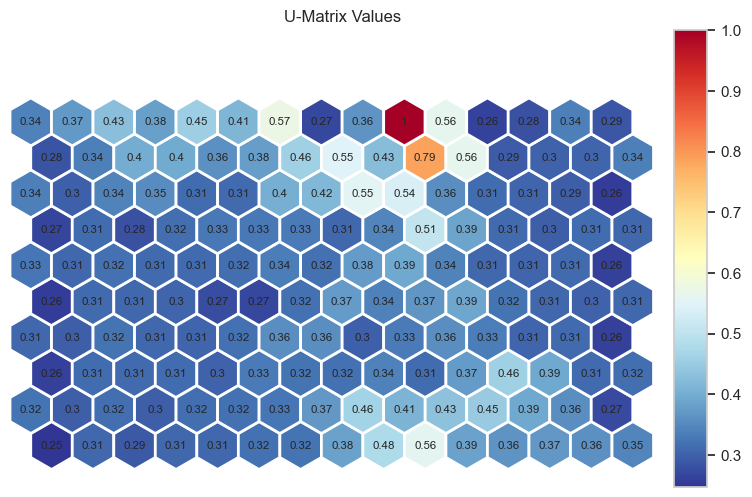

In [122]:
fig = plt.figure(figsize=(9,6))
umx_annot = get_index_matrix(10,10)

plot_hexagons(umatrix,
              sm, fig, 
              label="U-Matrix Values",      # Add Component Plane title
              cmap=cm.RdYlBu_r , 
              annot_mx=np.round(umatrix,2))

plt.show()

The __U-Matrix__ confirms the presence of clear boundaries between these identified groups, indicating robust cluster separation.

##### Hit-map 

In [123]:
hitsmatrix = sm.activation_response(df_out[behaviour_features].values)

## Values of HITS:
## Flip and rotate to match plot
np.flip(np.round(hitsmatrix,2), axis=1).T

array([[1.710e+02, 1.240e+02, 8.800e+01, 6.600e+01, 1.610e+02, 7.500e+01,
        7.200e+01, 0.000e+00, 1.484e+03, 1.000e+00, 9.600e+01, 1.290e+02,
        1.440e+02, 1.030e+02, 1.530e+02],
       [1.230e+02, 1.020e+02, 5.800e+01, 7.200e+01, 9.300e+01, 1.020e+02,
        7.400e+01, 3.100e+01, 7.000e+00, 4.500e+01, 1.090e+02, 9.600e+01,
        1.300e+02, 1.080e+02, 1.480e+02],
       [1.510e+02, 8.900e+01, 8.000e+01, 6.800e+01, 1.010e+02, 1.160e+02,
        1.410e+02, 8.400e+01, 1.840e+02, 4.300e+01, 1.030e+02, 1.310e+02,
        1.000e+02, 1.050e+02, 1.440e+02],
       [1.080e+02, 1.230e+02, 1.080e+02, 7.200e+01, 6.900e+01, 1.000e+02,
        1.180e+02, 1.070e+02, 2.600e+01, 8.900e+01, 1.030e+02, 8.700e+01,
        1.020e+02, 1.030e+02, 1.460e+02],
       [1.040e+02, 1.050e+02, 1.470e+02, 1.010e+02, 8.200e+01, 7.000e+01,
        8.000e+01, 6.800e+01, 8.900e+01, 6.300e+01, 9.900e+01, 1.310e+02,
        1.030e+02, 9.900e+01, 1.320e+02],
       [8.200e+01, 1.020e+02, 1.090e+02, 9.400e+01

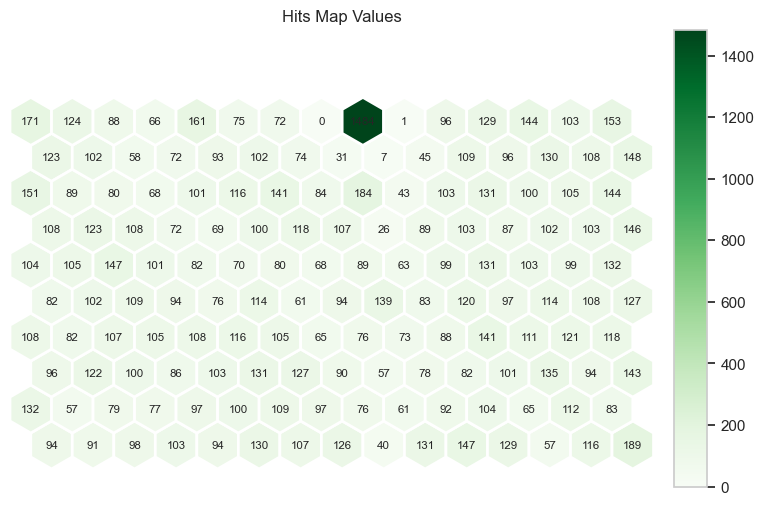

In [124]:
fig = plt.figure(figsize=(9,6))

plot_hexagons(hitsmatrix,
              sm, fig, 
              label="Hits Map Values",
              cmap=cm.Greens , 
              annot_mx=np.round(hitsmatrix,2))

plt.show()

The __Hits Map__ shows a generally even distribution of data across neurons, with one significant outlier cluster containing over 1,400 samples.

##### SOM K-Means clustering map

Reshaped weights_flat shape: (150, 9)
K-Means cluster matrix shape: (15, 10)


<Figure size 1000x600 with 0 Axes>

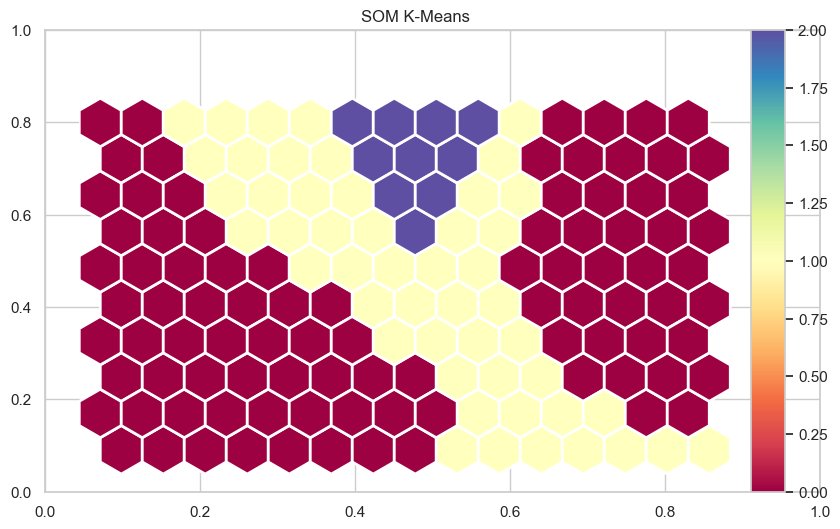

In [125]:
# Ensure df_dem matches the SOM feature size
num_features_som = weights.shape[2]
if len(df_dem.columns) != num_features_som:
    print(f"Warning: df_dem has {len(df_dem.columns)} features, "
          f"but SOM expects {num_features_som}. Selecting first {num_features_som} columns.")
    df_dem = df_dem.iloc[:, :num_features_som]

# Flatten SOM weights for K-Means
weights_flat = weights.reshape((-1, num_features_som))
print(f"Reshaped weights_flat shape: {weights_flat.shape}")

# Apply K-Means clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=20, random_state=42)
nodeclus_labels = kmeans.fit_predict(weights_flat)

# Reshape labels back to SOM grid
som_shape = weights.shape[:2]  # e.g., (15, 10)
kmeans_matrix = nodeclus_labels.reshape(som_shape)
print(f"K-Means cluster matrix shape: {kmeans_matrix.shape}")

# Plot using your existing plot_hexagons function
fig = plt.figure(figsize=(10, 6))  # adjust figsize as needed
colornorm = mpl_colors.Normalize(vmin=0, vmax=np.max(kmeans_matrix))

fig, ax = plt.subplots(figsize=(10,6))  # create figure/subplot
plot_hexagons(
    kmeans_matrix,   # som_matrix
    sm,              # your SOM object
    fig,             # figure
    label="SOM K-Means",
    cmap=cm.Spectral
)
plt.show()



The final graph represents the __SOM K-Means clustering__, which partitions the trained map into three distinct segments based on the weight vectors of the neurons. The purple cluster at the top center corresponds to the high-density outlier identified in the __Hits Map__, representing a highly concentrated group ofr customers. Surrounding it, the yellow cluster acts as a transitional group, while the large red clusters on the periphery capture more varied behavioral patterns. This visualization simplifies the complex high-dimensional data into a clear map for targeted business strategy, effectively separating unique customer personas.

## 8. Merging clusters
Now closing we will do a merge analysis of our clusters.

In [126]:
kmeans_demo = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    random_state=42
)
demo_labels = kmeans_demo.fit_predict(df_dem)
demo_labels

array([0, 1, 1, ..., 3, 3, 3], shape=(16321,), dtype=int32)

In [127]:
df_out['demographic_cluster'] = demo_labels

In [128]:

kmeans_pref = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)
beha_labels = kmeans_pref.fit_predict(df_beh)
beha_labels

array([0, 0, 0, ..., 0, 1, 1], shape=(16321,), dtype=int32)

In [129]:
df_out['behaviour_cluster'] = beha_labels

In [130]:
crosstab = pd.crosstab(df_out['demographic_cluster'], df_out['behaviour_cluster'])
crosstab

behaviour_cluster,0,1,2
demographic_cluster,,,
0,3989,12,216
1,5333,0,204
2,501,1547,3264
3,869,163,223


The resulting cross-tabulation table reveals several key strategic insights:

*  __Behavior__ Cluster 0 is the largest, capturing over 10,600 customers across all __demographi__c segments, particularly concentrated in __Demographic__ Clusters 0 and 1.
* __Behavior__ Cluster 1 is highly exclusive, almost entirely populated by __Demographic__ Cluster 2 (1,547 customers), representing a unique lifestyle-behavior pairing.
* __ Demographic__ Cluster 2 also shows significant activity in Behavior Cluster 2 (3,264 customers), indicating this specific demographic is the most active and diverse in their engagement.

In [131]:
df_centroids = df_out.groupby(['demographic_cluster', 'behaviour_cluster'])[metric_features].mean()
df_centroids

Income  Customer Lifetime Value  \
demographic_cluster behaviour_cluster                                     
0                   0                  1.04146                 -0.23655   
                    1                  1.88618                 -0.17560   
                    2                  1.11853                 -0.23009   
1                   0                 -0.75793                 -0.29491   
                    2                 -0.82306                 -0.34381   
2                   0                 -0.13221                 -0.33996   
                    1                  0.01385                 -0.24121   
                    2                 -0.03531                 -0.24159   
3                   0                 -0.10713                  2.09113   
                    1                 -0.05977                  2.62674   
                    2                  0.07044                  2.22240   

                                       ProgramDaysDuration  TotalFlights  \
demographic_cluster behaviour_cluster                                      
0                   0                              0.40360       0.65341   
                    1                              1.61554      -1.73621   
                    2                              0.24495      -0.42776   
1                   0                              0.39239       0.67299   
                    2                              0.51216      -0.39579   
2                   0                             -0.85371       0.07292   
                    1                             -0.04232      -1.73143   
                    2                             -1.07104      -1.06480   
3                   0                              0.28622       0.59146   
                    1                              0.52807      -1.74554   
                    2                             -0.89978      -0.90320   

                                       TotalPointsRedeemed  Flights_Summer  \
demographic_cluster behaviour_cluster                                        
0                   0                              0.35296         0.54367   
                    1                             -0.99541        -1.41995   
                    2                              0.11326        -0.36083   
1                   0                              0.46862         0.56760   
                    2                              0.16580        -0.34279   
2                   0                             -0.63988        -0.00609   
                    1                             -0.99541        -1.41926   
                    2                             -0.64773        -0.89305   
3                   0                              0.05875         0.45972   
                    1                             -0.99541        -1.41995   
                    2                             -0.58142        -0.79596   

                                       Flights_Spring  Flights_Winter  \
demographic_cluster behaviour_cluster                                   
0                   0                         0.53725         0.50540   
                    1                        -1.28168        -1.41025   
                    2                        -0.36845        -0.36633   
1                   0                         0.56028         0.53108   
                    2                        -0.24870        -0.33472   
2                   0                        -0.08903         0.07861   
                    1                        -1.32790        -1.36581   
                    2                        -0.92082        -0.84174   
3                   0                         0.49951         0.47140   
                    1                        -1.32794        -1.39346   
                    2                        -0.82773        -0.68226   

                                       Flights_Fall  \
demographic_cluster behaviour_cluster                 


In [132]:
# Using Hierarchical clustering to merge the concatenated cluster centroids
linkage = 'ward'
hclust = AgglomerativeClustering(
    linkage=linkage, 
    metric='euclidean', 
    distance_threshold=0, 
    n_clusters=None
)

hclust_labels = hclust.fit_predict(df_centroids)

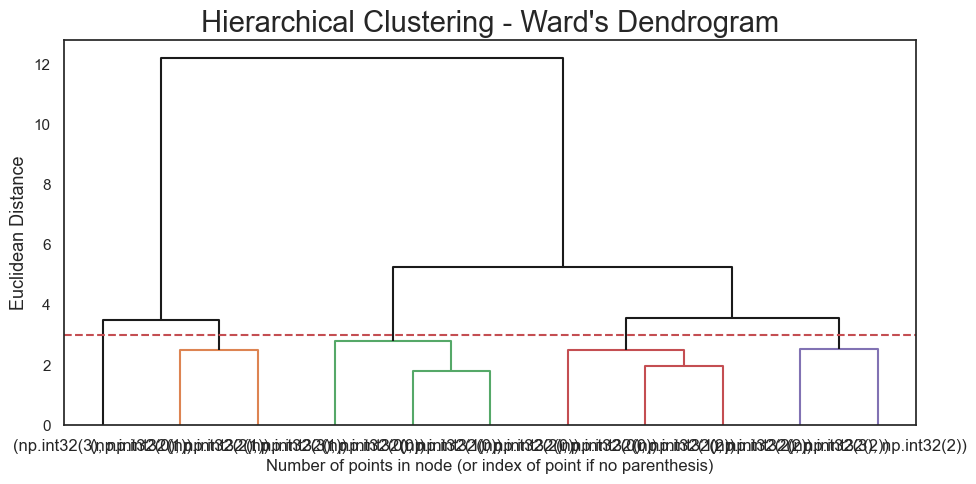

In [133]:
## create the counts of samples under each node (number of points being merged)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

# hclust.children_ contains the observation ids that are being merged together
# At the i-th iteration, children[i][0] and children[i][1] are merged to form node n_samples + i
for i, merge in enumerate(hclust.children_):
    # track the number of observations in the current cluster being formed
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            # If this is True, then we are merging an observation
            current_count += 1  # leaf node
        else:
            # Otherwise, we are merging a previously formed cluster
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

# the hclust.children_ is used to indicate the two points/clusters being merged (dendrogram's u-joins)
# the hclust.distances_ indicates the distance between the two points/clusters (height of the u-joins)
# the counts indicate the number of points being merged (dendrogram's x-axis)
linkage_matrix = np.column_stack(
    [hclust.children_, hclust.distances_, counts]
).astype(float)

# Plot the corresponding dendrogram
sns.set_style("white")
fig = plt.figure(figsize=(11,5))

# The Dendrogram parameters need to be tuned
y_threshold = 3
dendrogram(linkage_matrix, 
           truncate_mode='level', 
           labels=df_centroids.index, p=5, 
           color_threshold=y_threshold, 
           above_threshold_color='k')

# Add a horizontal line at the threshold
plt.hlines(y_threshold, 0, 1000, colors="r", linestyles="dashed")

# Set the title and labels
plt.title(f'Hierarchical Clustering - {linkage.title()}\'s Dendrogram', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Euclidean Distance', fontsize=13)



# Display the plot
plt.show()

From the __dendrogram__, it is observed that the data is divided into 4 main cluster for the merged perpective. 

In [134]:
# Re-running the Hierarchical clustering based on the correct number of clusters
hclust = AgglomerativeClustering(
    linkage='ward', 
    metric='euclidean', 
    n_clusters=4
)
hclust_labels = hclust.fit_predict(df_centroids)
df_centroids['hclust_labels'] = hclust_labels

df_centroids 

Income  Customer Lifetime Value  \
demographic_cluster behaviour_cluster                                     
0                   0                  1.04146                 -0.23655   
                    1                  1.88618                 -0.17560   
                    2                  1.11853                 -0.23009   
1                   0                 -0.75793                 -0.29491   
                    2                 -0.82306                 -0.34381   
2                   0                 -0.13221                 -0.33996   
                    1                  0.01385                 -0.24121   
                    2                 -0.03531                 -0.24159   
3                   0                 -0.10713                  2.09113   
                    1                 -0.05977                  2.62674   
                    2                  0.07044                  2.22240   

                                       ProgramDaysDuration  TotalFlights  \
demographic_cluster behaviour_cluster                                      
0                   0                              0.40360       0.65341   
                    1                              1.61554      -1.73621   
                    2                              0.24495      -0.42776   
1                   0                              0.39239       0.67299   
                    2                              0.51216      -0.39579   
2                   0                             -0.85371       0.07292   
                    1                             -0.04232      -1.73143   
                    2                             -1.07104      -1.06480   
3                   0                              0.28622       0.59146   
                    1                              0.52807      -1.74554   
                    2                             -0.89978      -0.90320   

                                       TotalPointsRedeemed  Flights_Summer  \
demographic_cluster behaviour_cluster                                        
0                   0                              0.35296         0.54367   
                    1                             -0.99541        -1.41995   
                    2                              0.11326        -0.36083   
1                   0                              0.46862         0.56760   
                    2                              0.16580        -0.34279   
2                   0                             -0.63988        -0.00609   
                    1                             -0.99541        -1.41926   
                    2                             -0.64773        -0.89305   
3                   0                              0.05875         0.45972   
                    1                             -0.99541        -1.41995   
                    2                             -0.58142        -0.79596   

                                       Flights_Spring  Flights_Winter  \
demographic_cluster behaviour_cluster                                   
0                   0                         0.53725         0.50540   
                    1                        -1.28168        -1.41025   
                    2                        -0.36845        -0.36633   
1                   0                         0.56028         0.53108   
                    2                        -0.24870        -0.33472   
2                   0                        -0.08903         0.07861   
                    1                        -1.32790        -1.36581   
                    2                        -0.92082        -0.84174   
3                   0                         0.49951         0.47140   
                    1                        -1.32794        -1.39346   
                    2                        -0.82773        -0.68226   

                                       Flights_Fall  \
demographic_cluster behaviour_cluster                 


In [135]:
cluster_mapper = df_centroids['hclust_labels'].to_dict()
cluster_mapper


{(0, 0): 2,
 (0, 1): 0,
 (0, 2): 3,
 (1, 0): 2,
 (1, 2): 3,
 (2, 0): 3,
 (2, 1): 0,
 (2, 2): 1,
 (3, 0): 2,
 (3, 1): 0,
 (3, 2): 1}

In [136]:
df_ = df_out.copy()
df_

,Income,Customer Lifetime Value,TotalFlights,TotalFlightsWithCompanions,TotalPointsRedeemed,MaxFlightsInMonth,MaxPointsInMonth,SoloFlightRatio,PointsRatio,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter,ProgramDaysDuration,demographic_cluster,behaviour_cluster
0,1.06797,-0.64205,0.58979,0.88506,0.58684,0.09267,0.41247,-0.49461,0.00107,0.29764,0.54478,1.23172,-0.57511,-0.19897,0,0
1,-1.24409,-0.64197,1.70478,-0.14355,1.63325,0.27567,0.26553,0.92849,0.97558,1.16760,2.09574,1.23172,1.00237,-0.22995,1,0
2,-1.24409,-0.64195,-0.26504,0.15646,-0.35403,-0.45633,0.07977,-0.78326,-0.13669,-0.11444,0.21826,-0.78860,-0.01835,0.61922,1,0
3,-1.24409,-0.64195,0.66412,0.97078,0.91617,0.09267,0.09456,-0.51618,0.58849,0.48079,1.40189,-0.28352,0.81679,1.34164,1,0
4,1.98051,-0.64147,0.35440,1.14221,-0.99541,0.45867,-0.08011,-1.06693,-0.99962,-0.02286,-0.18988,0.88448,0.30642,0.47417,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,-0.51935,4.43724,0.57740,0.62791,0.75527,-0.09033,0.84868,-0.28849,0.61836,0.61815,0.09582,0.56881,0.63120,0.83890,3,0
16882,-1.24409,4.43724,-1.75170,-1.51502,-0.99541,-2.65233,-2.68347,1.83802,-0.99962,-1.48805,-1.33270,-1.41995,-1.41025,0.95297,3,1
16891,-1.24409,4.43724,0.70128,0.02789,-0.44899,-0.09033,0.40693,0.37325,-0.52795,0.48079,0.05500,0.78978,0.90958,0.02916,3,0
16894,0.77709,4.43724,-1.75170,-1.51502,-0.99541,-2.65233,-2.68347,1.83802,-0.99962,-1.48805,-1.33270,-1.41995,-1.41025,0.34461,3,1


In [137]:
df_['merged_labels'] = df_.apply(
    lambda row: cluster_mapper[
        ( row['demographic_cluster'],row['behaviour_cluster'])
    ], axis=1
)

df_

,Income,Customer Lifetime Value,TotalFlights,TotalFlightsWithCompanions,TotalPointsRedeemed,MaxFlightsInMonth,MaxPointsInMonth,SoloFlightRatio,PointsRatio,Flights_Fall,Flights_Spring,Flights_Summer,Flights_Winter,ProgramDaysDuration,demographic_cluster,behaviour_cluster,merged_labels
0,1.06797,-0.64205,0.58979,0.88506,0.58684,0.09267,0.41247,-0.49461,0.00107,0.29764,0.54478,1.23172,-0.57511,-0.19897,0,0,2
1,-1.24409,-0.64197,1.70478,-0.14355,1.63325,0.27567,0.26553,0.92849,0.97558,1.16760,2.09574,1.23172,1.00237,-0.22995,1,0,2
2,-1.24409,-0.64195,-0.26504,0.15646,-0.35403,-0.45633,0.07977,-0.78326,-0.13669,-0.11444,0.21826,-0.78860,-0.01835,0.61922,1,0,2
3,-1.24409,-0.64195,0.66412,0.97078,0.91617,0.09267,0.09456,-0.51618,0.58849,0.48079,1.40189,-0.28352,0.81679,1.34164,1,0,2
4,1.98051,-0.64147,0.35440,1.14221,-0.99541,0.45867,-0.08011,-1.06693,-0.99962,-0.02286,-0.18988,0.88448,0.30642,0.47417,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,-0.51935,4.43724,0.57740,0.62791,0.75527,-0.09033,0.84868,-0.28849,0.61836,0.61815,0.09582,0.56881,0.63120,0.83890,3,0,2
16882,-1.24409,4.43724,-1.75170,-1.51502,-0.99541,-2.65233,-2.68347,1.83802,-0.99962,-1.48805,-1.33270,-1.41995,-1.41025,0.95297,3,1,0
16891,-1.24409,4.43724,0.70128,0.02789,-0.44899,-0.09033,0.40693,0.37325,-0.52795,0.48079,0.05500,0.78978,0.90958,0.02916,3,0,2
16894,0.77709,4.43724,-1.75170,-1.51502,-0.99541,-2.65233,-2.68347,1.83802,-0.99962,-1.48805,-1.33270,-1.41995,-1.41025,0.34461,3,1,0


### 8.1. Final analysis of the merged

In [138]:
cluster_sizes = df_['merged_labels'].value_counts().sort_index()  # Cluster sizes
total_points = df_.shape[0]  # Total number of data points

# Calculate percentages
cluster_percentages = (cluster_sizes / total_points) * 100

# Convert to list 
cluster_sizes_list = cluster_sizes.tolist()
cluster_percentages_list = cluster_percentages.tolist()

# Print the results
print("Cluster Sizes:", cluster_sizes_list)
print("Cluster Percentages:", cluster_percentages_list)

Cluster Sizes: [1722, 3487, 10191, 921]
Cluster Percentages: [10.55082409166105, 21.365112431836284, 62.441026897861654, 5.643036578641015]


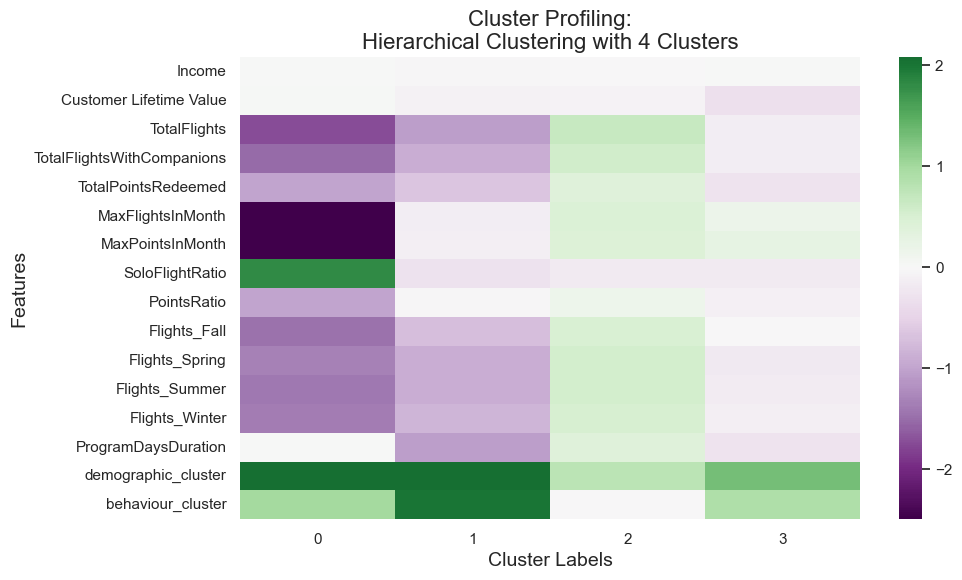

In [139]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))  

# Compute the mean profile for each cluster
hc_profile = df_.groupby('merged_labels').mean().T

# Plot the heatmap with a new color palette
sns.heatmap(
    hc_profile,
    center=0, 
    annot=False,  
    cmap="PRGn",
    fmt=".2f",
    ax=ax
)


ax.set_xlabel("Cluster Labels", fontsize=14)
ax.set_ylabel("Features", fontsize=14)  # Adding this for clarity
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 4 Clusters", fontsize=16)

plt.show()


From the __cluster profiling__ we can take some insides:
* __Cluster 0__: High-Value Solo Travelers This segment displays a high `SoloFlightRatio` (indicated by the deep green), paired with low seasonal flight activity (purple). Despite their high __demographic__ and __behavioral__ cluster scores, they are not high-volume fliers but are very distinct in their solo travel preference.
* __Cluster 1__: Consistent Low-Engagement Users Characterized by neutral or low values across almost all __behavioral__ features, this group represents the "baseline" customer. They show moderate duration in the program but minimal flight activity across all seasons.
* __Cluster 2__: This is a highly active segment showing strong positive engagement (green) across all seasons (Fall, Spring, Summer, and Winter). They are consistent fliers with a high `TotalFlights` count and high `TotalFlightsWithCompanions`, suggesting they are likely leisure travelers or families.
* __Cluster 3__: This group shows moderate engagement across most features. While they don't peak in seasonal flights like __Cluster 2__, they maintain steady participation and contribute significantly to the overall customer base.

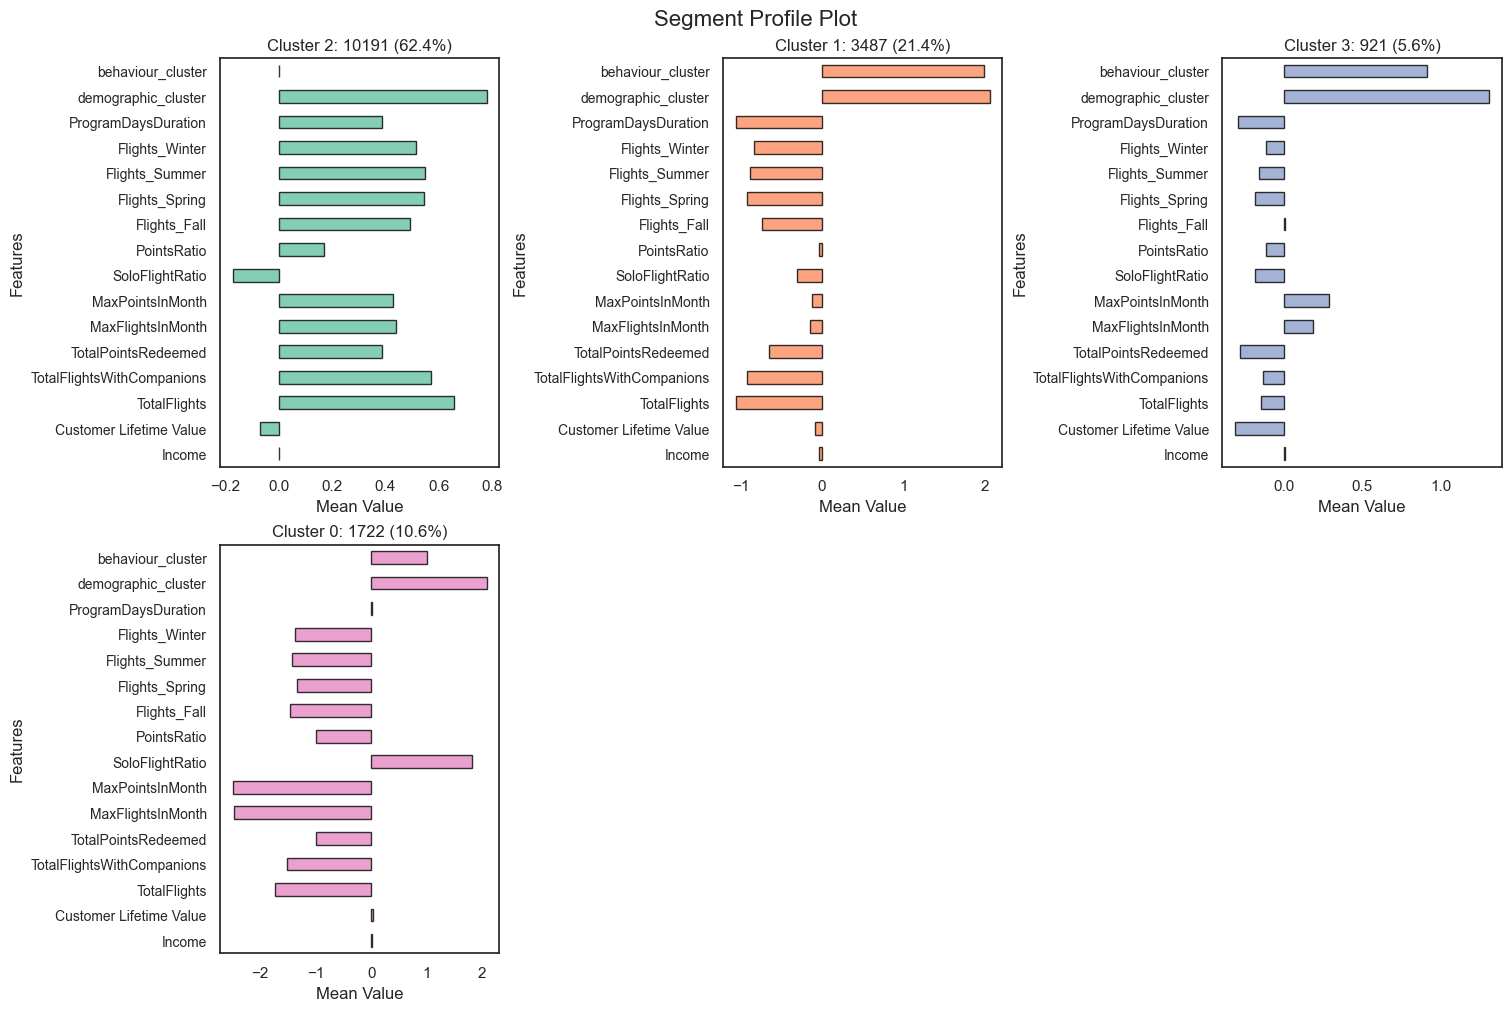

In [140]:
data = df_
clusters = data['merged_labels'].unique()

# Calculate cluster sizes and percentages
cluster_sizes = data['merged_labels'].value_counts().sort_index()
total_size = len(data)
cluster_percentages = (cluster_sizes / total_size) * 100

# Calculate mean profiles for each cluster
hc_profile = data.groupby('merged_labels').mean()

# Plot setup
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)  # Adjust based on cluster count
axes = axes.flatten()

colors = sns.color_palette("Set2", len(clusters))  # Custom color palette for each cluster

for idx, (cluster, ax) in enumerate(zip(clusters, axes)):
    # Bar plot for the cluster
    mean_profile = hc_profile.loc[cluster]
    mean_profile.plot.barh(
        ax=ax,
        color=colors[idx],
        alpha=0.8,
        edgecolor='black'
    )
    
    # Add cluster size and percentage to title
    cluster_size = cluster_sizes[cluster]
    cluster_percentage = cluster_percentages[cluster]
    ax.set_title(f"Cluster {cluster}: {cluster_size} ({cluster_percentage:.1f}%)", fontsize=12)
    ax.set_xlabel("Mean Value")
    ax.set_ylabel("Features")
    ax.tick_params(axis='y', labelsize=10)

# Remove unused axes 
for extra_ax in axes[len(clusters):]:
    extra_ax.set_visible(False)

# Overall plot title
fig.suptitle("Segment Profile Plot", fontsize=16)

plt.show()

The analysis reveals from our four clusters that categorize the entire customer base:
* __Cluster 2__ (62.4% - The Core Engaged Segment): This is the largest group, characterized by high positive mean values across almost all engagement metrics, including `TotalFlights`, `TotalFlightsWithCompanions`, and seasonal flight activity. They represent the most consistent and valuable revenue stream for the program.
* __Cluster 1__ (21.4% - Low-Engagement Users): These customers show significant negative mean values for flight frequency and points redeemed. They are largely inactive across all seasons despite having a high __demographic_cluster__ score.
* __Cluster 0__ (10.6% - Solo Travelers): This niche group is defined by an exceptionally high `SoloFlightRatio` and high __demographic_cluster__ score. However, they show the lowest participation in seasonal flights and total points redemption.
* __Cluster 3__ (5.6% - ): This small but distinct segment has the highest __demographic_cluster__ and __behaviour_cluster__ scores. While their current flight frequency is lower than Cluster 2, their high scores suggest they are a prime target for premium service upselling.